This notebook performs:
1. **Task 1 - Market Basket Construction**: Grouping transactions into baskets and filtering for meaningful sizes
2. **Task 2 - Product Affinity Metrics**: Calculating support, confidence, and lift for product pairs
3. **Task 3 - Category-Level Affinity Analysis**: Department and commodity level affinity analysis with anchor identification
4. **Task 4 - Promotional Impact Analysis**: Analysing promotion effects on affinity purchases and halo effects
5. **Task 5 - Customer Segmentation**: K-Means clustering of households by shopping behaviour
6. **Task 6 - Recommendation Engine**: Building and testing a recommendation prototype

In [1]:
import pandas as pd
import numpy as np
from itertools import combinations
from collections import defaultdict
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# For better display in notebooks
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 50)

In [2]:
# Load the datasets
print("Loading data files...")

transaction_data = pd.read_csv('transaction_data.csv')
product_data = pd.read_csv('product.csv')

print(f"Transaction data shape: {transaction_data.shape}")
print(f"Product data shape: {product_data.shape}")

Loading data files...
Transaction data shape: (2595732, 12)
Product data shape: (92353, 7)


In [3]:
# Preview the data
print("Transaction Data Sample:")
display(transaction_data.head())

print("\nProduct Data Sample:")
display(product_data.head())

Transaction Data Sample:


,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0



Product Data Sample:


,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [4]:
# =============================================================================
# TASK 1: MARKET BASKET CONSTRUCTION 
# =============================================================================

# Group by basket_id to identify complete shopping baskets
baskets = transaction_data.groupby('BASKET_ID').agg({
    'PRODUCT_ID': list,
    'household_key': 'first',
    'DAY': 'first',
    'QUANTITY': 'sum',
    'SALES_VALUE': 'sum'
}).reset_index()

baskets['BASKET_SIZE'] = baskets['PRODUCT_ID'].apply(len)

print(f"Total baskets: {len(baskets):,}")
print(f"Average basket size: {baskets['BASKET_SIZE'].mean():.2f} items")
print(f"Median basket size: {baskets['BASKET_SIZE'].median():.0f} items")

display(baskets.head())

Total baskets: 276,484
Average basket size: 9.39 items
Median basket size: 5 items


,BASKET_ID,PRODUCT_ID,household_key,DAY,QUANTITY,SALES_VALUE,BASKET_SIZE
0,26984851472,"[1004906, 1033142, 1036325, 1082185, 8160430]",2375,1,5,5.91,5
1,26984851516,"[826249, 1043142, 1085983, 1102651, 6423775, 9...",2375,1,7,12.43,6
2,26984896261,"[842930, 897044, 920955, 937406, 981760]",1364,1,5,11.37,5
3,26984905972,"[833715, 866950, 1022843, 1048462, 1071333]",1130,1,9,2.55,5
4,26984945254,"[824399, 923972, 1131351]",1173,1,4,3.53,3


In [5]:
# Basket size distribution
print("Basket Size Distribution:")
print(baskets['BASKET_SIZE'].describe())

print("\nValue counts for basket sizes 1-10:")
print(baskets['BASKET_SIZE'].value_counts().sort_index().head(10))

Basket Size Distribution:
count    276484.000000
mean          9.388362
std          12.283792
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max         168.000000
Name: BASKET_SIZE, dtype: float64

Value counts for basket sizes 1-10:
1     60045
2     32846
3     24655
4     19046
5     15337
6     12720
7     10769
8      9022
9      8093
10     7100
Name: BASKET_SIZE, dtype: int64


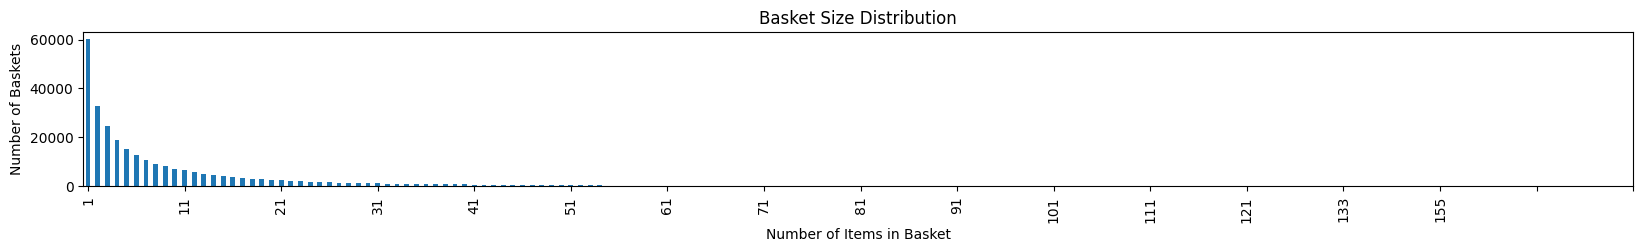


Basket Size Description:
count    276484.000000
mean          9.388362
std          12.283792
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max         168.000000
Name: BASKET_SIZE, dtype: float64


In [6]:
# Filter for Meaningful Basket Sizes (3+ items)

# make a plot showing basket size distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 2))
baskets['BASKET_SIZE'].value_counts().sort_index().plot(kind='bar')
# make x axis ticks more spread out
plt.xticks(ticks=np.arange(0, baskets['BASKET_SIZE'].max()+0, 10))
plt.title('Basket Size Distribution')
plt.xlabel('Number of Items in Basket')
plt.ylabel('Number of Baskets')
plt.show()
# Print description of basket sizes
print("\nBasket Size Description:")
print(baskets['BASKET_SIZE'].describe())


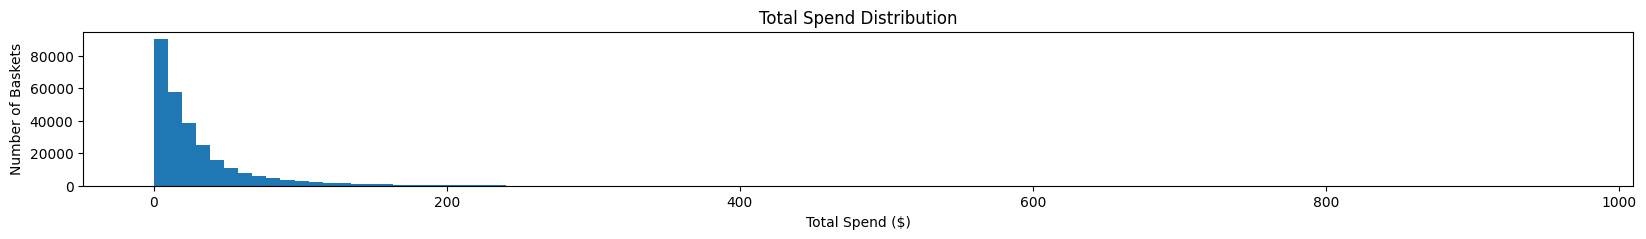


Total Spend Description:
count    276484.000000
mean         29.142602
std          36.101301
min           0.000000
25%           6.960000
50%          17.070000
75%          36.280000
max         961.490000
Name: SALES_VALUE, dtype: float64


In [7]:
# make a plot showing total spend distribution
plt.figure(figsize=(20, 2))
baskets['SALES_VALUE'].plot(kind='hist', bins=100)
plt.title('Total Spend Distribution')
plt.xlabel('Total Spend ($)')
plt.ylabel('Number of Baskets')
plt.show()
# Print description of total spend
print("\nTotal Spend Description:")
print(baskets['SALES_VALUE'].describe())



Percentage of baskets with more than 4 items: 50.60% (139,892 out of 276,484)


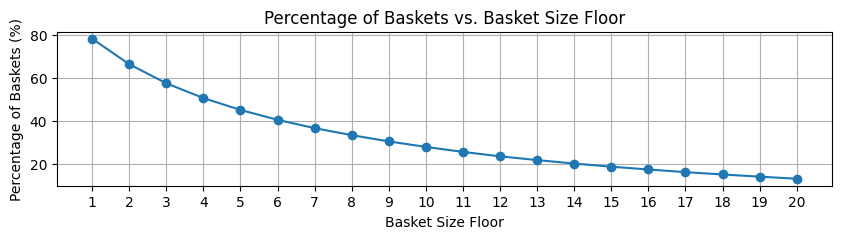


Percentage of baskets with spend over $50: 16.61% (45,928 out of 276,484)


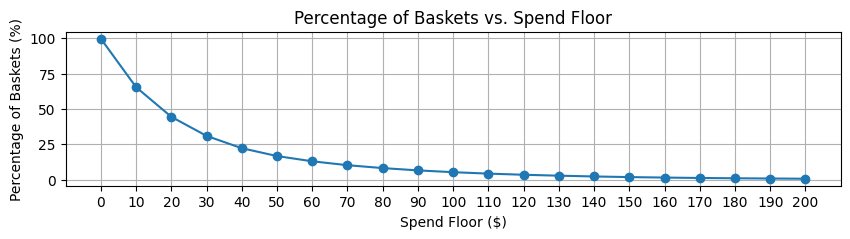

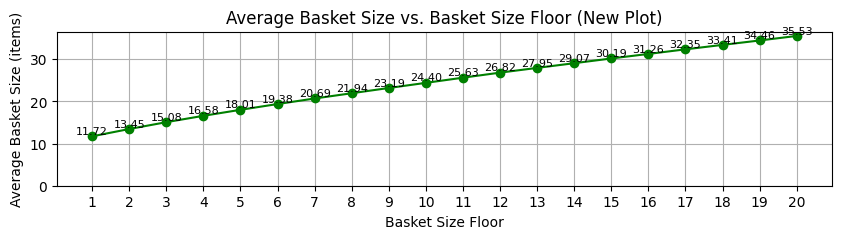

In [8]:
# what percentage of baskets have more than basket_floor items?
basket_floor = 4
large_baskets = baskets[baskets['BASKET_SIZE'] > basket_floor]
print(f"\nPercentage of baskets with more than {basket_floor} items: "
      f"{len(large_baskets) / len(baskets) * 100:.2f}% "
      f"({len(large_baskets):,} out of {len(baskets):,})")
# plot percentage of baskets depending of basket_floor from 1 to 20
basket_floors = range(1, 21)
percentages = []
for floor in basket_floors:
    large_baskets = baskets[baskets['BASKET_SIZE'] > floor]
    percentages.append(len(large_baskets) / len(baskets) * 100)
plt.figure(figsize=(10, 2))
plt.plot(basket_floors, percentages, marker='o')
plt.title('Percentage of Baskets vs. Basket Size Floor')
plt.xlabel('Basket Size Floor')
plt.ylabel('Percentage of Baskets (%)')
plt.xticks(basket_floors)
plt.grid()
plt.show()
# what percentage of baskets are value over spend_floor?
spend_floor = 50
high_value_baskets = baskets[baskets['SALES_VALUE'] > spend_floor]
print(f"\nPercentage of baskets with spend over ${spend_floor}: "
      f"{len(high_value_baskets) / len(baskets) * 100:.2f}% "
      f"({len(high_value_baskets):,} out of {len(baskets):,})")
# plot percentage of baskets depending of spend_floor from 0 to 200
spend_floors = range(0, 201, 10)
percentages = []
for floor in spend_floors:
    high_value_baskets = baskets[baskets['SALES_VALUE'] > floor]
    percentages.append(len(high_value_baskets) / len(baskets) * 100)
plt.figure(figsize=(10, 2))
plt.plot(spend_floors, percentages, marker='o')
plt.title('Percentage of Baskets vs. Spend Floor')
plt.xlabel('Spend Floor ($)')
plt.ylabel('Percentage of Baskets (%)')
plt.xticks(spend_floors)
plt.grid()
plt.show()
# also plot average basklet size depending on basket_floor from 1 to 20
# Create a new plot for average basket size depending on basket_floor from 1 to 20
avg_sizes = []
for floor in basket_floors:
    large_baskets = baskets[baskets['BASKET_SIZE'] > floor]
    avg_sizes.append(large_baskets['BASKET_SIZE'].mean())

plt.figure(figsize=(10, 2))
plt.plot(basket_floors, avg_sizes, marker='o', color='green')
plt.title('Average Basket Size vs. Basket Size Floor (New Plot)')
# min value of y is zero
plt.ylim(0, max(avg_sizes) + 1)
plt.xlabel('Basket Size Floor')
plt.ylabel('Average Basket Size (items)')
plt.xticks(basket_floors)
plt.grid()

# Add data labels to show y-axis values
for x, y in zip(basket_floors, avg_sizes):
    plt.text(x, y, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

plt.show()



In [9]:
# Filter for meaningful basket sizes: based on the analysis above, we will keep baskets with 3 or more unique items and priced at $10 (assumed crncy) or more
meaningful_baskets = baskets[(baskets['BASKET_SIZE'] >= 3) & (baskets['SALES_VALUE'] >= 10)].copy()

print(f"Baskets with 3+ items and priced at $10 or more: {len(meaningful_baskets):,}")
print(f"Percentage retained: {len(meaningful_baskets)/len(baskets)*100:.1f}%")
print(f"Average basket size (filtered): {meaningful_baskets['BASKET_SIZE'].mean():.2f} items")

display(meaningful_baskets.head())

Baskets with 3+ items and priced at $10 or more: 150,237
Percentage retained: 54.3%
Average basket size (filtered): 15.56 items


,BASKET_ID,PRODUCT_ID,household_key,DAY,QUANTITY,SALES_VALUE,BASKET_SIZE
1,26984851516,"[826249, 1043142, 1085983, 1102651, 6423775, 9...",2375,1,7,12.43,6
2,26984896261,"[842930, 897044, 920955, 937406, 981760]",1364,1,5,11.37,5
6,26985025264,"[877180, 878664, 930917, 940796, 981760, 99997...",1172,1,19,44.78,17
7,26985040735,"[820162, 827656, 829617, 833014, 833598, 84655...",1060,1,57,139.22,50
10,26985205886,"[822346, 830887, 866211, 866518, 869577, 89099...",212,1,29,69.26,24


In [10]:
# Create Detailed Basket View with Product Metadata
# Explode the product lists to get one row per basket-product combination
basket_products = meaningful_baskets[['BASKET_ID', 'PRODUCT_ID']].copy()
basket_products = basket_products.explode('PRODUCT_ID')

print(f"Total basket-product combinations: {len(basket_products):,}")
display(basket_products.head(10))

Total basket-product combinations: 2,337,070


,BASKET_ID,PRODUCT_ID
1,26984851516,826249
1,26984851516,1043142
1,26984851516,1085983
1,26984851516,1102651
1,26984851516,6423775
1,26984851516,9487839
2,26984896261,842930
2,26984896261,897044
2,26984896261,920955
2,26984896261,937406


In [11]:
# Merge with product details
basket_products = basket_products.merge(
    product_data[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 
             'MANUFACTURER', 'BRAND', 'CURR_SIZE_OF_PRODUCT']],
    on='PRODUCT_ID',
    how='left'
)

print(f"Products with metadata: {basket_products['DEPARTMENT'].notna().sum():,}")
print(f"Missing metadata: {basket_products['DEPARTMENT'].isna().sum():,}")

display(basket_products.head(10))

Products with metadata: 2,337,070
Missing metadata: 0


,BASKET_ID,PRODUCT_ID,DEPARTMENT,COMMODITY_DESC,SUB_COMMODITY_DESC,MANUFACTURER,BRAND,CURR_SIZE_OF_PRODUCT
0,26984851516,826249,GROCERY,BAKED BREAD/BUNS/ROLLS,HAMBURGER BUNS,69,Private,12 OZ
1,26984851516,1043142,DRUG GM,BROOMS AND MOPS,SPONGES: BATH HOUSEHOLD,321,National,
2,26984851516,1085983,GROCERY,COOKIES/CONES,TRAY PACK/CHOC CHIP COOKIES,586,National,18 OZ
3,26984851516,1102651,GROCERY,PNT BTR/JELLY/JAMS,PEANUT BUTTER,1266,National,12 OZ
4,26984851516,6423775,GROCERY,COOKIES/CONES,GRAHAM CRACKERS,586,National,11 OZ
5,26984851516,9487839,GROCERY,COOKIES/CONES,GRAHAM CRACKERS,586,National,11 OZ
6,26984896261,842930,GROCERY,CONVENIENT BRKFST/WHLSM SNACKS,GRANOLA BARS,69,Private,10 OZ
7,26984896261,897044,GROCERY,CRACKERS/MISC BKD FD,SNACK CRACKERS,1075,National,9.5 OZ
8,26984896261,920955,MEAT,BEEF,GRND/PATTY - ROUND,3664,National,
9,26984896261,937406,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES,LINKS - RAW,2209,National,12OZ


In [12]:
# Display sample baskets
# find index of basket number in meaningful_baskets given BASKET_ID
basket_loc = meaningful_baskets[meaningful_baskets['BASKET_ID'] == 26985360571].index[0]
sample_basket = meaningful_baskets.loc[basket_loc]

print(f"Example Basket ID: {sample_basket['BASKET_ID']}")
print(f"Basket size: {sample_basket['BASKET_SIZE']} items")
print(f"Total value: ${sample_basket['SALES_VALUE']:.2f}")
print(f"Day: {sample_basket['DAY']}")
print("\nProducts in basket:")

sample_products = basket_products[basket_products['BASKET_ID'] == sample_basket['BASKET_ID']]
display(sample_products[['PRODUCT_ID', 'BRAND', 'COMMODITY_DESC', 'DEPARTMENT']])

Example Basket ID: 26985360571
Basket size: 85 items
Total value: $168.48
Day: 1

Products in basket:


,PRODUCT_ID,BRAND,COMMODITY_DESC,DEPARTMENT
108,830503,National,LUNCHMEAT,MEAT-PCKGD
109,839605,National,FROZEN MEAT,MEAT-PCKGD
110,840664,National,CANDY - PACKAGED,DRUG GM
111,844685,Private,DINNER MXS:DRY,GROCERY
112,848015,Private,MEAT - SHELF STABLE,GROCERY
...,...,...,...,...
188,9297177,National,COLD CEREAL,GROCERY
189,9368449,National,CHIPS&SNACKS,NUTRITION
190,9487500,Private,BABY HBC,DRUG GM
191,9553031,Private,SOUP,GROCERY


In [13]:
# =============================================================================
# TASK 2: PRODUCT AFFINITY METRICS
# =============================================================================

# Create product pairs for each basket
product_pairs = []
total_baskets_analyzed = len(meaningful_baskets)

print("Generating product pairs...")
for idx, row in meaningful_baskets.iterrows():
    products = row['PRODUCT_ID']
    # Generate all unique pairs from this basket
    if len(products) >= 2:
        pairs = list(combinations(sorted(set(products)), 2))
        product_pairs.extend(pairs)

print(f"Total product pair occurrences: {len(product_pairs):,}")
print(f"Example pairs: {product_pairs[:5]}")

Generating product pairs...
Total product pair occurrences: 31,484,957
Example pairs: [(826249, 1043142), (826249, 1085983), (826249, 1102651), (826249, 6423775), (826249, 9487839)]


In [14]:
# Count pair frequencies
pair_counts = pd.DataFrame(product_pairs, columns=['product_A', 'product_B'])
pair_counts = pair_counts.groupby(['product_A', 'product_B']).size().reset_index(name='pair_count')

print(f"Unique product pairs: {len(pair_counts):,}")
display(pair_counts.sort_values('pair_count', ascending=False).head(10))

Unique product pairs: 19,257,764


,product_A,product_B,pair_count
14169446,1029743,1082185,3383
12526337,995242,1082185,2876
11851497,981760,1082185,2510
16172982,1082185,1127831,2320
16171357,1082185,1106523,2065
10782166,961554,1082185,1880
3787165,860776,1082185,1732
10255740,951590,1082185,1721
16172916,1082185,1126899,1700
12571165,995785,1082185,1641


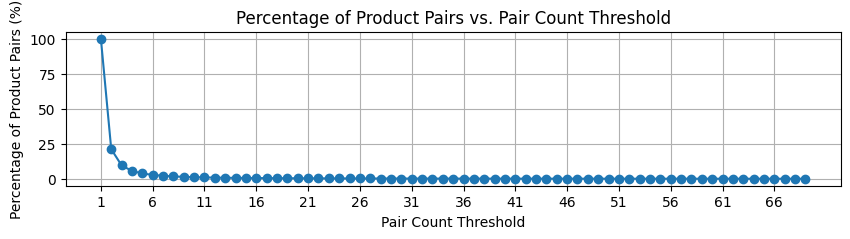

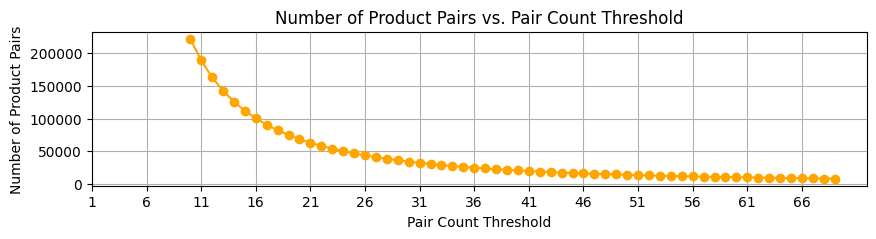

In [15]:
# plot percentage of pairs that have a pair count above a certain threshold
thresholds = range(1, 70)
percentages = []
for threshold in thresholds:
    count_above_threshold = len(pair_counts[pair_counts['pair_count'] >= threshold])
    percentages.append(count_above_threshold / len(pair_counts) * 100)
plt.figure(figsize=(10, 2))
plt.plot(thresholds, percentages, marker='o')
plt.title('Percentage of Product Pairs vs. Pair Count Threshold')
plt.xlabel('Pair Count Threshold')
plt.ylabel('Percentage of Product Pairs (%)')
plt.xticks(ticks=range(1, 70, 5))  # Adjust x-axis ticks to spread out more
plt.grid()
plt.show()

# plot number of pairs that have a pair count above a certain threshold
thresholds = range(10, 70)
counts = []
for threshold in thresholds:
    count_above_threshold = len(pair_counts[pair_counts['pair_count'] >= threshold])
    counts.append(count_above_threshold)
plt.figure(figsize=(10, 2))
plt.plot(thresholds, counts, marker='o', color='orange')
plt.title('Number of Product Pairs vs. Pair Count Threshold')
plt.xlabel('Pair Count Threshold')
plt.ylabel('Number of Product Pairs')
plt.xticks(ticks=range(1, 70, 5))  # Adjust x-axis ticks to spread out more
plt.grid()
plt.show()



In [16]:
# keep only the pairs that have a pair count of at least min_pair_count
# will create separate sets for department or commodity level analysis later
min_pair_count = 20
# what percentage of the pair_counts dataframe will be kept?
initial_pair_count = len(pair_counts)
pair_counts = pair_counts[pair_counts['pair_count'] >= min_pair_count]
final_pair_count = len(pair_counts)
# print out percentage kept
print(f"\nPairs with at least {min_pair_count} co-occurrences: {final_pair_count:,}")
print(f"Percentage retained: {final_pair_count/initial_pair_count*100:.5f}%")



Pairs with at least 20 co-occurrences: 68,553
Percentage retained: 0.35598%


In [17]:
# Calculate individual product frequencies (for confidence and lift)
product_counts = {}
for products in meaningful_baskets['PRODUCT_ID']:
    for product in set(products):
        product_counts[product] = product_counts.get(product, 0) + 1

print(f"Unique products: {len(product_counts):,}")

# Show top products by frequency and their name from product dataframe
top_products = sorted(product_counts.items(), key=lambda x: x[1], reverse=True)[:10]
print("\nTop 10 most frequent products:")
for prod_id, count in top_products:
    product_name = product_data.loc[product_data['PRODUCT_ID'] == prod_id, 'COMMODITY_DESC'].values[0]
    print(f"  Product {prod_id} ({product_name}): {count:,} baskets ({count/total_baskets_analyzed*100:.2f}%)")

Unique products: 88,330

Top 10 most frequent products:
  Product 1082185 (TROPICAL FRUIT): 27,320 baskets (18.18%)
  Product 1029743 (FLUID MILK PRODUCTS): 12,654 baskets (8.42%)
  Product 995242 (FLUID MILK PRODUCTS): 10,824 baskets (7.20%)
  Product 981760 (EGGS): 8,413 baskets (5.60%)
  Product 1106523 (FLUID MILK PRODUCTS): 8,392 baskets (5.59%)
  Product 883404 (BAKED BREAD/BUNS/ROLLS): 6,155 baskets (4.10%)
  Product 1133018 (FLUID MILK PRODUCTS): 6,106 baskets (4.06%)
  Product 951590 (BAKED BREAD/BUNS/ROLLS): 5,707 baskets (3.80%)
  Product 1127831 (BERRIES): 5,056 baskets (3.37%)
  Product 826249 (BAKED BREAD/BUNS/ROLLS): 4,966 baskets (3.31%)


In [18]:
# Support: Percentage of baskets containing both products
pair_counts['support'] = pair_counts['pair_count'] / total_baskets_analyzed

# Confidence A->B: P(B|A) = count(A,B) / count(A)
pair_counts['confidence_A_to_B'] = pair_counts.apply(
    lambda x: x['pair_count'] / product_counts.get(x['product_A'], 1), axis=1
)

# Confidence B->A: P(A|B) = count(A,B) / count(B)
pair_counts['confidence_B_to_A'] = pair_counts.apply(
    lambda x: x['pair_count'] / product_counts.get(x['product_B'], 1), axis=1
)

# Lift A->B: P(B|A) / P(B)
pair_counts['lift_A_to_B'] = pair_counts.apply(
    lambda x: (x['pair_count'] / product_counts.get(x['product_A'], 1)) / 
              (product_counts.get(x['product_B'], 1) / total_baskets_analyzed), 
    axis=1
)

# Lift B->A: P(A|B) / P(A)
pair_counts['lift_B_to_A'] = pair_counts.apply(
    lambda x: (x['pair_count'] / product_counts.get(x['product_B'], 1)) / 
              (product_counts.get(x['product_A'], 1) / total_baskets_analyzed), 
    axis=1
)

print("Affinity metrics calculated!")
display(pair_counts.head(10))

Affinity metrics calculated!


,product_A,product_B,pair_count,support,confidence_A_to_B,confidence_B_to_A,lift_A_to_B,lift_B_to_A
63754,108646,117847,27,0.000180,0.794118,0.586957,2593.605499,2593.605499
63897,108646,6408076,22,0.000146,0.647059,0.550000,2430.304412,2430.304412
67134,117847,6408076,27,0.000180,0.586957,0.675000,2204.564674,2204.564674
123297,818980,1082185,39,0.000260,0.325000,0.001428,1.787226,1.787226
125278,818981,1029743,26,0.000173,0.240741,0.002055,2.858240,2.858240
125543,818981,1082185,57,0.000379,0.527778,0.002086,2.902333,2.902333
128148,819063,826249,22,0.000146,0.080000,0.004430,2.420250,2.420250
128353,819063,844179,21,0.000140,0.076364,0.005632,3.076601,3.076601
128401,819063,847982,22,0.000146,0.080000,0.009430,5.151719,5.151719
128428,819063,849843,23,0.000153,0.083636,0.005890,3.217740,3.217740


In [19]:
# Add product details for both products in the pair
pair_counts = pair_counts.merge(
    product_data[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'BRAND']].add_suffix('_A'),
    left_on='product_A',
    right_on='PRODUCT_ID_A',
    how='left'
).merge(
    product_data[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC', 'SUB_COMMODITY_DESC', 'BRAND']].add_suffix('_B'),
    left_on='product_B',
    right_on='PRODUCT_ID_B',
    how='left'
)


In [20]:

print("Product metadata added!")
display(pair_counts[['product_A', 'product_B', 'BRAND_A', 'BRAND_B', 
                      'COMMODITY_DESC_A', 'COMMODITY_DESC_B', 'support', 
                      'lift_A_to_B', 'lift_B_to_A']].head())

Product metadata added!


,product_A,product_B,BRAND_A,BRAND_B,COMMODITY_DESC_A,COMMODITY_DESC_B,support,lift_A_to_B,lift_B_to_A
0,108646,117847,National,National,REFRIGERATED,REFRIGERATED,0.000180,2593.605499,2593.605499
1,108646,6408076,National,National,REFRIGERATED,REFRIGERATED,0.000146,2430.304412,2430.304412
2,117847,6408076,National,National,REFRIGERATED,REFRIGERATED,0.000180,2204.564674,2204.564674
3,818980,1082185,National,National,BEANS - CANNED GLASS & MW,TROPICAL FRUIT,0.000260,1.787226,1.787226
4,818981,1029743,National,Private,COLD CEREAL,FLUID MILK PRODUCTS,0.000173,2.858240,2.858240


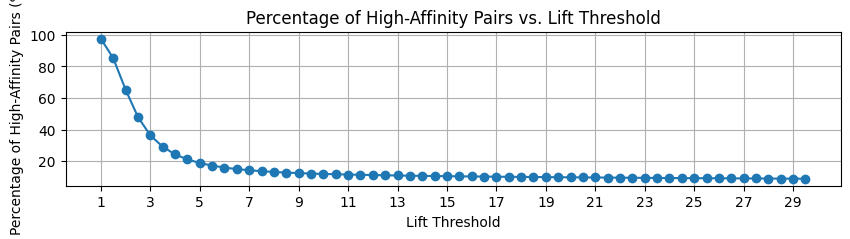

In [21]:
# plot percentage of vlaues in high affinity dataset where lift is above a given threshold from 1.5 to 5.0
lift_thresholds = np.arange(1, 30, 0.5)
percentages = []
for threshold in lift_thresholds:
    count = len(pair_counts[
        (pair_counts['lift_A_to_B'] > threshold) | (pair_counts['lift_B_to_A'] > threshold)
    ])
    percentages.append(count / len(pair_counts) * 100)
plt.figure(figsize=(10, 2))
plt.plot(lift_thresholds, percentages, marker='o')
plt.title('Percentage of High-Affinity Pairs vs. Lift Threshold')
plt.xlabel('Lift Threshold')
plt.ylabel('Percentage of High-Affinity Pairs (%)')
plt.xticks(ticks=np.arange(1, 30, 2))  # Adjust x-axis ticks to spread out more
plt.grid()
plt.show()


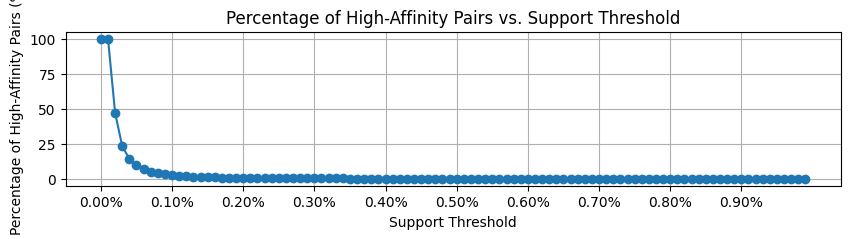

In [22]:
from matplotlib.ticker import FuncFormatter

# Plot percentage of pairs that have support higher than a given threshold from 0% to 10%
support_thresholds = np.arange(0, 0.01, 0.0001)
percentages = []
for threshold in support_thresholds:
    count = len(pair_counts[pair_counts['support'] > threshold])
    percentages.append(count / len(pair_counts) * 100)

plt.figure(figsize=(10, 2))
plt.plot(support_thresholds, percentages, marker='o')

# Format x-axis ticks as percentages
formatter = FuncFormatter(lambda x, _: f"{x * 100:.2f}%")
plt.gca().xaxis.set_major_formatter(formatter)

plt.title('Percentage of High-Affinity Pairs vs. Support Threshold')
plt.xlabel('Support Threshold')
plt.ylabel('Percentage of High-Affinity Pairs (%)')
plt.xticks(ticks=np.arange(0, 0.01, 0.001))  # Adjust x-axis ticks to spread out more
plt.grid()
plt.show()


In [23]:
# remove rows in pair_counts where DEPARTMENT_A or DEPARTMENT_B is ' ' and calculate how many such pair we removed
initial_count = len(pair_counts)
pair_counts = pair_counts[
    (pair_counts['DEPARTMENT_A'].notna()) & (pair_counts['DEPARTMENT_A'] != ' ') &
    (pair_counts['DEPARTMENT_B'].notna()) & (pair_counts['DEPARTMENT_B'] != ' ')
]
final_count = len(pair_counts)
removed_count = initial_count - final_count
print(f"\nRemoved {removed_count:,} pairs with missing department info.")



Removed 1,023 pairs with missing department info.


In [24]:
pair_counts['avg_lift'] = (pair_counts['lift_A_to_B'] + pair_counts['lift_B_to_A']) / 2

# Strict filtering for product-level recommendations
product_level_pairs = pair_counts[
    (pair_counts['pair_count'] >= 100) &
    (pair_counts['avg_lift'] >= 1.5) &
    (pair_counts['avg_lift'] <= 10)
]
# Use this for: Product bundles, specific SKU promotions

# Relaxed filtering for department-level strategy
department_level_pairs = pair_counts[
    (pair_counts['pair_count'] >= 30) &      # Much lower threshold
    (pair_counts['avg_lift'] >= 1.2) &        # Lower lift threshold
    (pair_counts['avg_lift'] <= 15)           # Higher ceiling
]
# Use this for: Store layout, department adjacency, high-level strategy

In [25]:
# make sure not entry in the pair_counts has PRODUCT_ID_A equal to PRODUCT_ID_B
if len(pair_counts[pair_counts['product_A'] == pair_counts['product_B']]) == 0:
    print("No pairs with identical products found.")

No pairs with identical products found.


In [26]:
# Display top affinity pairs
print("Top 20 Product Pairs by Average Lift:")
display(department_level_pairs[[
    'PRODUCT_ID_A', 'BRAND_A', 'COMMODITY_DESC_A', 'SUB_COMMODITY_DESC_A', 'DEPARTMENT_A',
    'PRODUCT_ID_B', 'BRAND_B', 'COMMODITY_DESC_B', 'SUB_COMMODITY_DESC_B', 'DEPARTMENT_B',
    'pair_count', 'support', 'confidence_A_to_B', 'confidence_B_to_A',
    'lift_A_to_B', 'lift_B_to_A', 'avg_lift'
]].head(20))

Top 20 Product Pairs by Average Lift:


,PRODUCT_ID_A,BRAND_A,COMMODITY_DESC_A,SUB_COMMODITY_DESC_A,DEPARTMENT_A,PRODUCT_ID_B,BRAND_B,COMMODITY_DESC_B,SUB_COMMODITY_DESC_B,DEPARTMENT_B,pair_count,support,confidence_A_to_B,confidence_B_to_A,lift_A_to_B,lift_B_to_A,avg_lift
3,818980,National,BEANS - CANNED GLASS & MW,PREPARED BEANS - BAKED W/PORK,GROCERY,1082185,National,TROPICAL FRUIT,BANANAS,PRODUCE,39,0.000260,0.325000,0.001428,1.787226,1.787226,1.787226
5,818981,National,COLD CEREAL,ALL FAMILY CEREAL,GROCERY,1082185,National,TROPICAL FRUIT,BANANAS,PRODUCE,57,0.000379,0.527778,0.002086,2.902333,2.902333,2.902333
17,819063,National,PASTA SAUCE,MAINSTREAM,GROCERY,981760,Private,EGGS,EGGS - X-LARGE,GROCERY,38,0.000253,0.138182,0.004517,2.467612,2.467612,2.467612
19,819063,National,PASTA SAUCE,MAINSTREAM,GROCERY,995785,National,PEPPERS-ALL,PEPPERS GREEN BELL,PRODUCE,35,0.000233,0.127273,0.007212,3.940052,3.940052,3.940052
20,819063,National,PASTA SAUCE,MAINSTREAM,GROCERY,1029743,Private,FLUID MILK PRODUCTS,FLUID MILK WHITE ONLY,GROCERY,40,0.000266,0.145455,0.003161,1.726937,1.726937,1.726937
21,819063,National,PASTA SAUCE,MAINSTREAM,GROCERY,1044078,National,BEEF,LEAN,MEAT,30,0.000200,0.109091,0.008028,4.385735,4.385735,4.385735
22,819063,National,PASTA SAUCE,MAINSTREAM,GROCERY,1082185,National,TROPICAL FRUIT,BANANAS,PRODUCE,81,0.000539,0.294545,0.002965,1.619752,1.619752,1.619752
27,819255,National,BREAKFAST SAUSAGE/SANDWICHES,ROLLS - PORK,MEAT-PCKGD,826249,Private,BAKED BREAD/BUNS/ROLLS,HAMBURGER BUNS,GROCERY,36,0.000240,0.093750,0.007249,2.836230,2.836230,2.836230
29,819255,National,BREAKFAST SAUSAGE/SANDWICHES,ROLLS - PORK,MEAT-PCKGD,840361,Private,EGGS,EGGS - LARGE,GROCERY,32,0.000213,0.083333,0.006491,2.539503,2.539503,2.539503
33,819255,National,BREAKFAST SAUSAGE/SANDWICHES,ROLLS - PORK,MEAT-PCKGD,859075,Private,CHEESE,SHREDDED CHEESE,GROCERY,31,0.000206,0.080729,0.009411,3.682000,3.682000,3.682000


In [27]:
# Analyze cross-department affinities
department_level_pairs['same_department'] = department_level_pairs['DEPARTMENT_A'] == department_level_pairs['DEPARTMENT_B']

print("Cross-Department vs Same-Department Affinities:")
print(f"Same department pairs: {department_level_pairs['same_department'].sum():,}")
print(f"Cross-department pairs: {(~department_level_pairs['same_department']).sum():,}")

print("\nTop cross-department affinities:")
cross_dept = department_level_pairs[~department_level_pairs['same_department']]
display(cross_dept[[
    'DEPARTMENT_A', 'COMMODITY_DESC_A', 'BRAND_A',
    'DEPARTMENT_B', 'COMMODITY_DESC_B', 'BRAND_B',
    'support', 'avg_lift'
]].head(10))

Cross-Department vs Same-Department Affinities:
Same department pairs: 13,500
Cross-department pairs: 14,681

Top cross-department affinities:


,DEPARTMENT_A,COMMODITY_DESC_A,BRAND_A,DEPARTMENT_B,COMMODITY_DESC_B,BRAND_B,support,avg_lift
3,GROCERY,BEANS - CANNED GLASS & MW,National,PRODUCE,TROPICAL FRUIT,National,0.000260,1.787226
5,GROCERY,COLD CEREAL,National,PRODUCE,TROPICAL FRUIT,National,0.000379,2.902333
19,GROCERY,PASTA SAUCE,National,PRODUCE,PEPPERS-ALL,National,0.000233,3.940052
21,GROCERY,PASTA SAUCE,National,MEAT,BEEF,National,0.000200,4.385735
22,GROCERY,PASTA SAUCE,National,PRODUCE,TROPICAL FRUIT,National,0.000539,1.619752
27,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES,National,GROCERY,BAKED BREAD/BUNS/ROLLS,Private,0.000240,2.836230
29,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES,National,GROCERY,EGGS,Private,0.000213,2.539503
33,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES,National,GROCERY,CHEESE,Private,0.000206,3.682000
35,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES,National,GROCERY,BAKED BREAD/BUNS/ROLLS,Private,0.000246,2.351903
36,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES,National,PRODUCE,POTATOES,Private,0.000206,4.874802


In [28]:
# =============================================================================
# TASK 3: CATEGORY LEVEL AFFINITY ANALYSIS
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

In [29]:
# Aggregate product pairs to department level
dept_affinity = department_level_pairs.groupby(['DEPARTMENT_A', 'DEPARTMENT_B']).agg({
    'pair_count': 'sum',
    'support': 'mean',
    'lift_A_to_B': 'mean',
    'lift_B_to_A': 'mean'
}).reset_index()

# Calculate average lift
dept_affinity['avg_lift'] = (dept_affinity['lift_A_to_B'] + dept_affinity['lift_B_to_A']) / 2

print(f"Department-level affinity pairs: {len(dept_affinity):,}")
print(f"Unique departments: {pd.concat([dept_affinity['DEPARTMENT_A'], dept_affinity['DEPARTMENT_B']]).nunique()}")

display(dept_affinity.sort_values('avg_lift', ascending=False).head(10))

Department-level affinity pairs: 80
Unique departments: 17


,DEPARTMENT_A,DEPARTMENT_B,pair_count,support,lift_A_to_B,lift_B_to_A,avg_lift
6,DELI,PASTRY,120,0.000266,10.089108,10.089108,10.089108
2,DELI,DELI,7636,0.000424,9.357443,9.357443,9.357443
10,DRUG GM,DRUG GM,289,0.000275,9.317668,9.317668,9.317668
51,PASTRY,PASTRY,79,0.000526,8.611307,8.611307,8.611307
75,SALAD BAR,SALAD BAR,220,0.000366,7.808030,7.808030,7.808030
14,DRUG GM,SEAFOOD-PCKGD,31,0.000206,7.722449,7.722449,7.722449
40,MEAT-PCKGD,MEAT-PCKGD,1245,0.000267,7.147212,7.147212,7.147212
22,GROCERY,NUTRITION,181,0.000241,4.917921,4.917921,4.917921
78,TRAVEL & LEISUR,GROCERY,48,0.000319,4.351269,4.351269,4.351269
69,PRODUCE,TRAVEL & LEISUR,121,0.000268,3.845700,3.845700,3.845700


Departments kept (≥20% coverage): 9
Departments: ['DELI', 'DRUG GM', 'GROCERY', 'MEAT', 'MEAT-PCKGD', 'PASTRY', 'PRODUCE', 'SALAD BAR', 'SEAFOOD-PCKGD']


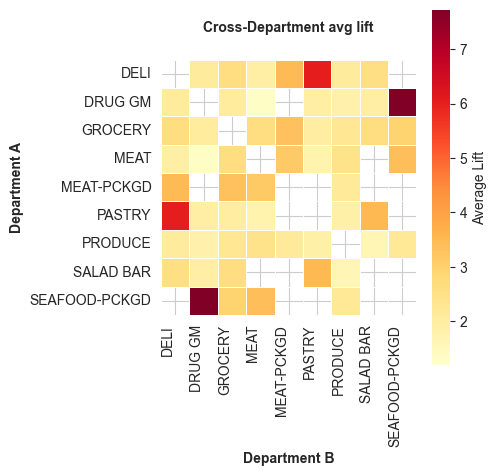


Matrix coverage: 69.1% of cells have data


In [30]:
# Exclude same-department pairs
cross_dept_affinity = dept_affinity[dept_affinity['DEPARTMENT_A'] != dept_affinity['DEPARTMENT_B']]

# Create pivot table for heatmap (using average lift) - USE NaN FOR MISSING VALUES
cross_dept_lift_matrix = cross_dept_affinity.pivot_table(
    index='DEPARTMENT_A',
    columns='DEPARTMENT_B',
    values='avg_lift',
    fill_value=np.nan  # Keep NaN for missing data
)

# Get all unique departments from both rows and columns
all_depts = sorted(list(set(cross_dept_lift_matrix.index) | set(cross_dept_lift_matrix.columns)))

# Reindex to make the matrix square
cross_dept_lift_matrix = cross_dept_lift_matrix.reindex(
    index=all_depts,
    columns=all_depts,
    fill_value=np.nan
)

# Now make symmetric using element-wise operation
# For each cell, take the average of (i,j) and (j,i), ignoring NaN
cross_dept_lift_matrix_sym = cross_dept_lift_matrix.copy()

for i in range(len(all_depts)):
    for j in range(len(all_depts)):
        val_ij = cross_dept_lift_matrix.iloc[i, j]
        val_ji = cross_dept_lift_matrix.iloc[j, i]
        
        if pd.notna(val_ij) and pd.notna(val_ji):
            # Both exist: average them
            cross_dept_lift_matrix_sym.iloc[i, j] = (val_ij + val_ji) / 2
        elif pd.notna(val_ij):
            # Only i->j exists: use it
            cross_dept_lift_matrix_sym.iloc[i, j] = val_ij
        elif pd.notna(val_ji):
            # Only j->i exists: use it
            cross_dept_lift_matrix_sym.iloc[i, j] = val_ji
        # else: both NaN, leave as NaN

# Remove sparse rows/columns for cleaner visualization
threshold = 0.2  # Keep departments with at least 30% data coverage
row_coverage = (~cross_dept_lift_matrix_sym.isna()).sum(axis=1) / len(cross_dept_lift_matrix_sym.columns)
col_coverage = (~cross_dept_lift_matrix_sym.isna()).sum(axis=0) / len(cross_dept_lift_matrix_sym.index)

departments_to_keep = sorted(list(
    set(cross_dept_lift_matrix_sym.index[row_coverage >= threshold]) &
    set(cross_dept_lift_matrix_sym.columns[col_coverage >= threshold])
))

print(f"Departments kept (≥{threshold*100:.0f}% coverage): {len(departments_to_keep)}")
print(f"Departments: {departments_to_keep}")

# Filter to keep only well-connected departments
cross_dept_lift_matrix_clean = cross_dept_lift_matrix_sym.loc[
    departments_to_keep, 
    departments_to_keep
]

# Create heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(
    cross_dept_lift_matrix_clean,
    annot=False,
    fmt='.2f',
    cmap='YlOrRd',
    cbar_kws={'label': 'Average Lift'},
    linewidths=0.5,
    square=True,
    vmin=1.2,  # Start color scale at minimum meaningful lift
    mask=cross_dept_lift_matrix_clean.isna()  # Mask NaN values so they appear blank
)
plt.title('Cross-Department avg lift', fontsize=10, fontweight='bold', pad=20)
plt.xlabel('Department B', fontsize=10, fontweight='bold')
plt.ylabel('Department A', fontsize=10, fontweight='bold')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nMatrix coverage: {(~cross_dept_lift_matrix_clean.isna()).sum().sum() / (len(departments_to_keep)**2) * 100:.1f}% of cells have data")

Departments kept (≥20% coverage): 9


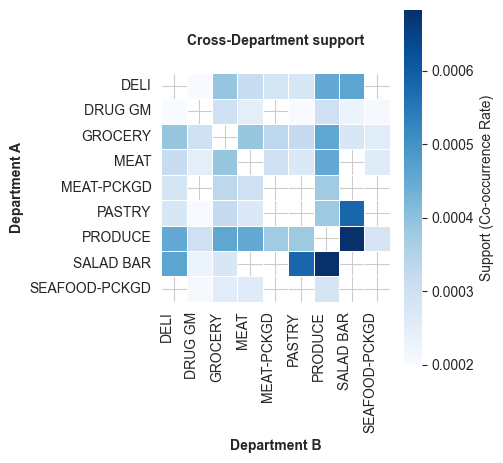


Matrix coverage: 69.1% of cells have data


In [31]:
# Exclude same-department pairs
cross_dept_affinity_support = dept_affinity[dept_affinity['DEPARTMENT_A'] != dept_affinity['DEPARTMENT_B']]

# Create pivot table for support (frequency) - USE NaN FOR MISSING VALUES
dept_support_matrix = cross_dept_affinity_support.pivot_table(
    index='DEPARTMENT_A',
    columns='DEPARTMENT_B',
    values='support',
    fill_value=np.nan  # Use NaN instead of 0 to avoid diluting real data
)

# Get all unique departments from both rows and columns
all_depts = sorted(list(set(dept_support_matrix.index) | set(dept_support_matrix.columns)))

# Reindex to make the matrix square
dept_support_matrix = dept_support_matrix.reindex(
    index=all_depts,
    columns=all_depts,
    fill_value=np.nan
)

# Make symmetric using element-wise operation to preserve single-direction data
dept_support_matrix_sym = dept_support_matrix.copy()

for i in range(len(all_depts)):
    for j in range(len(all_depts)):
        val_ij = dept_support_matrix.iloc[i, j]
        val_ji = dept_support_matrix.iloc[j, i]
        
        if pd.notna(val_ij) and pd.notna(val_ji):
            # Both exist: average them
            dept_support_matrix_sym.iloc[i, j] = (val_ij + val_ji) / 2
        elif pd.notna(val_ij):
            # Only i->j exists: use it
            dept_support_matrix_sym.iloc[i, j] = val_ij
        elif pd.notna(val_ji):
            # Only j->i exists: use it
            dept_support_matrix_sym.iloc[i, j] = val_ji
        # else: both NaN, leave as NaN

# Remove sparse rows/columns for cleaner visualization
threshold = 0.2  # Keep departments with at least 30% data coverage
row_coverage = (~dept_support_matrix_sym.isna()).sum(axis=1) / len(dept_support_matrix_sym.columns)
col_coverage = (~dept_support_matrix_sym.isna()).sum(axis=0) / len(dept_support_matrix_sym.index)

departments_to_keep = sorted(list(
    set(dept_support_matrix_sym.index[row_coverage >= threshold]) &
    set(dept_support_matrix_sym.columns[col_coverage >= threshold])
))

print(f"Departments kept (≥{threshold*100:.0f}% coverage): {len(departments_to_keep)}")

# Filter to keep only well-connected departments
dept_support_matrix_clean = dept_support_matrix_sym.loc[
    departments_to_keep, 
    departments_to_keep
]

# Create heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(
    dept_support_matrix_clean,
    annot=False,
    fmt='.4f',
    cmap='Blues',
    cbar_kws={'label': 'Support (Co-occurrence Rate)'},
    linewidths=0.5,
    square=True,
    mask=dept_support_matrix_clean.isna()  # Mask NaN values so they appear blank
)
plt.title('Cross-Department support', fontsize=10, fontweight='bold', pad=20)
plt.xlabel('Department B', fontsize=10, fontweight='bold')
plt.ylabel('Department A', fontsize=10, fontweight='bold')
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\nMatrix coverage: {(~dept_support_matrix_clean.isna()).sum().sum() / (len(departments_to_keep)**2) * 100:.1f}% of cells have data")

In [32]:
# Calculate cross-category purchase metrics for each department
# Anchor categories are those that drive high cross-category purchases

# Count distinct departments purchased with each department
dept_cross_category = cross_dept_affinity.groupby('DEPARTMENT_A').agg({
    'DEPARTMENT_B': 'count',  # Number of other departments it pairs with
    'pair_count': 'sum',  # Total cross-department pairs
    'avg_lift': 'mean'  # Average lift across all pairings
}).reset_index()

dept_cross_category.columns = ['DEPARTMENT', 'dept_connections', 'total_cross_pairs', 'avg_cross_lift']

# Also get the same for DEPARTMENT_B
dept_cross_category_b = cross_dept_affinity.groupby('DEPARTMENT_B').agg({
    'DEPARTMENT_A': 'count',
    'pair_count': 'sum',
    'avg_lift': 'mean'
}).reset_index()

dept_cross_category_b.columns = ['DEPARTMENT', 'dept_connections', 'total_cross_pairs', 'avg_cross_lift']

# Combine and aggregate
anchor_metrics = pd.concat([dept_cross_category, dept_cross_category_b]).groupby('DEPARTMENT').agg({
    'dept_connections': 'sum',
    'total_cross_pairs': 'sum',
    'avg_cross_lift': 'mean'
}).reset_index()

# Calculate anchor score (combination of connectivity and lift)
anchor_metrics['anchor_score'] = (
    (anchor_metrics['dept_connections'] / anchor_metrics['dept_connections'].max()) * 0.3 +
    (anchor_metrics['total_cross_pairs'] / anchor_metrics['total_cross_pairs'].max()) * 0.4 +
    (anchor_metrics['avg_cross_lift'] / anchor_metrics['avg_cross_lift'].max()) * 0.3
) * 100

anchor_metrics = anchor_metrics.sort_values('anchor_score', ascending=False)

print("Top 10 Anchor Categories (Drive Cross-Category Purchases):")
print("=" * 80)
display(anchor_metrics.head(10))

Top 10 Anchor Categories (Drive Cross-Category Purchases):


,DEPARTMENT,dept_connections,total_cross_pairs,avg_cross_lift,anchor_score
4,GROCERY,23,797068,2.679353,86.526201
11,PRODUCE,29,713743,2.278367,85.149335
1,DELI,13,64651,3.117419,43.142598
5,MEAT,14,162024,2.302916,42.152953
6,MEAT-PCKGD,8,103173,3.033191,39.188739
10,PASTRY,11,10800,3.026761,37.601987
9,NUTRITION,4,3251,3.535840,34.301079
15,SEAFOOD-PCKGD,6,1986,3.154223,33.068716
2,DRUG GM,10,13205,2.422867,31.564430
16,TRAVEL & LEISUR,4,609,3.207457,31.382307


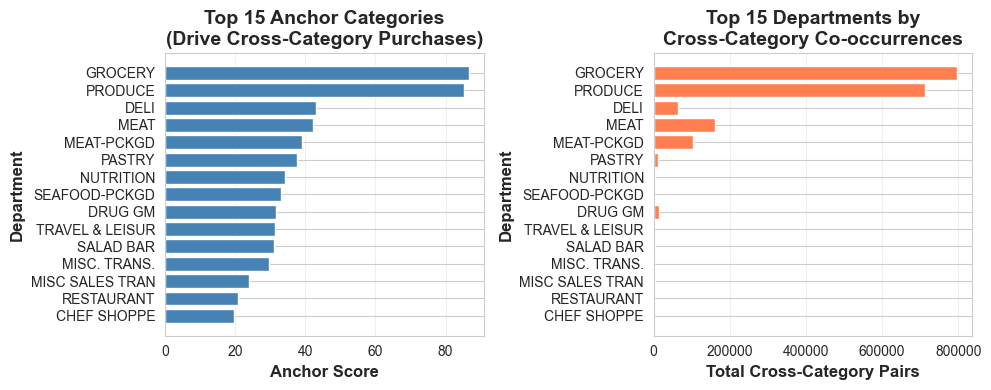


✓ Saved: anchor_categories.png


In [33]:
# Create bar chart of top anchor categories
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Anchor Score
top_anchors = anchor_metrics.head(15)
axes[0].barh(top_anchors['DEPARTMENT'], top_anchors['anchor_score'], color='steelblue')
axes[0].set_xlabel('Anchor Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Department', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Anchor Categories\n(Drive Cross-Category Purchases)', 
                  fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Total Cross-Category Pairs
axes[1].barh(top_anchors['DEPARTMENT'], top_anchors['total_cross_pairs'], color='coral')
axes[1].set_xlabel('Total Cross-Category Pairs', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Department', fontsize=12, fontweight='bold')
axes[1].set_title('Top 15 Departments by\nCross-Category Co-occurrences', 
                  fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('anchor_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: anchor_categories.png")

In [34]:
# Aggregate to commodity level (more granular than department)
commodity_affinity = product_level_pairs.groupby(['COMMODITY_DESC_A', 'COMMODITY_DESC_B']).agg({
    'pair_count': 'sum',
    'support': 'mean',
    'lift_A_to_B': 'mean',
    'lift_B_to_A': 'mean',
    'confidence_A_to_B': 'mean',
    'confidence_B_to_A': 'mean'
}).reset_index()

commodity_affinity['avg_lift'] = (commodity_affinity['lift_A_to_B'] + commodity_affinity['lift_B_to_A']) / 2
commodity_affinity['avg_confidence'] = (commodity_affinity['confidence_A_to_B'] + commodity_affinity['confidence_B_to_A']) / 2
commodity_affinity = commodity_affinity.sort_values('avg_lift', ascending=False)

print(f"Commodity-level affinity pairs: {len(commodity_affinity):,}")
print(f"\nTop 20 Commodity Pairs by Lift:")
display(commodity_affinity[[
    'COMMODITY_DESC_A', 'COMMODITY_DESC_B', 
    'pair_count', 'support', 'avg_lift'
]].head(20))

Commodity-level affinity pairs: 871

Top 20 Commodity Pairs by Lift:


,COMMODITY_DESC_A,COMMODITY_DESC_B,pair_count,support,avg_lift
288,DELI MEATS,CHEESES,143,0.000952,9.640465
621,REFRGRATD JUICES/DRNKS,REFRGRATD JUICES/DRNKS,104,0.000692,9.587797
478,MEAT - SHELF STABLE,SOUP,101,0.000672,9.091656
603,POTATOES,POTATOES,109,0.000726,9.059038
614,PWDR/CRYSTL DRNK MX,SUGARS/SWEETNERS,121,0.000805,8.942903
572,PEPPERS-ALL,PEPPERS-ALL,229,0.000762,8.724401
289,DELI MEATS,DELI MEATS,839,0.000931,8.568597
36,BAKED BREAD/BUNS/ROLLS,DINNER SAUSAGE,165,0.001098,8.548336
246,CITRUS,HERBS,242,0.000805,8.387669
483,MELONS,MELONS,144,0.000958,8.232415


Top 48 commodities selected
Commodities kept (≥50% coverage): 17


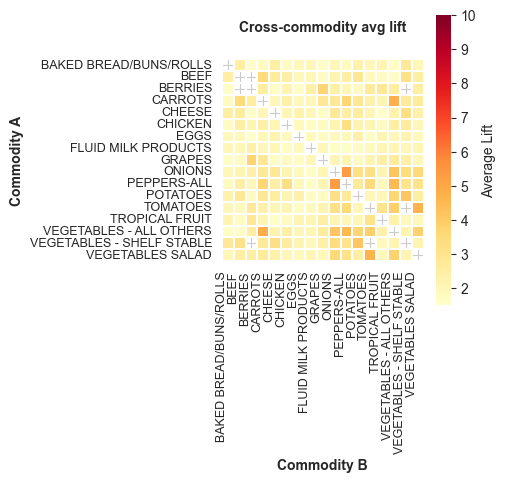


Matrix coverage: 92.0% of cells have data


In [35]:
# Exclude same-commodity pairs
cross_commodity_affinity = commodity_affinity[commodity_affinity['COMMODITY_DESC_A'] != commodity_affinity['COMMODITY_DESC_B']]

# Get top commodities by total pair count
top_commodities_a = cross_commodity_affinity.groupby('COMMODITY_DESC_A')['pair_count'].sum().nlargest(40).index
top_commodities_b = cross_commodity_affinity.groupby('COMMODITY_DESC_B')['pair_count'].sum().nlargest(40).index
top_commodities = sorted(list(set(top_commodities_a) | set(top_commodities_b)))

print(f"Top {len(top_commodities)} commodities selected")

# Filter for top commodities
top_commodity_affinity = cross_commodity_affinity[
    cross_commodity_affinity['COMMODITY_DESC_A'].isin(top_commodities) &
    cross_commodity_affinity['COMMODITY_DESC_B'].isin(top_commodities)
]

# Create pivot table - USE NaN FOR MISSING VALUES
commodity_matrix = top_commodity_affinity.pivot_table(
    index='COMMODITY_DESC_A',
    columns='COMMODITY_DESC_B',
    values='avg_lift',
    fill_value=np.nan  # Critical: use NaN not 0
)

# Reindex to make square matrix
commodity_matrix = commodity_matrix.reindex(
    index=top_commodities,
    columns=top_commodities,
    fill_value=np.nan
)

# Make symmetric while preserving single-direction data
commodity_matrix_sym = commodity_matrix.copy()

for i in range(len(top_commodities)):
    for j in range(len(top_commodities)):
        val_ij = commodity_matrix.iloc[i, j]
        val_ji = commodity_matrix.iloc[j, i]
        
        if pd.notna(val_ij) and pd.notna(val_ji):
            # Both exist: average them
            commodity_matrix_sym.iloc[i, j] = (val_ij + val_ji) / 2
        elif pd.notna(val_ij):
            # Only i->j exists: use it
            commodity_matrix_sym.iloc[i, j] = val_ij
        elif pd.notna(val_ji):
            # Only j->i exists: use it
            commodity_matrix_sym.iloc[i, j] = val_ji
        # else: both NaN, leave as NaN

# Remove sparse commodities for cleaner visualization
threshold = 0.5  # Keep commodities with at least x% data coverage
row_coverage = (~commodity_matrix_sym.isna()).sum(axis=1) / len(commodity_matrix_sym.columns)
col_coverage = (~commodity_matrix_sym.isna()).sum(axis=0) / len(commodity_matrix_sym.index)

commodities_to_keep = sorted(list(
    set(commodity_matrix_sym.index[row_coverage >= threshold]) &
    set(commodity_matrix_sym.columns[col_coverage >= threshold])
))

print(f"Commodities kept (≥{threshold*100:.0f}% coverage): {len(commodities_to_keep)}")

# Filter matrix
commodity_matrix_clean = commodity_matrix_sym.loc[commodities_to_keep, commodities_to_keep]

# Create heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(
    commodity_matrix_clean,
    annot=False,  # Too many cells to annotate
    cmap='YlOrRd',
    cbar_kws={'label': 'Average Lift'},
    linewidths=0.1,
    square=True,
    vmin=1.5,  # Start at meaningful lift threshold
    vmax=10,  # Cap at reasonable max
    mask=commodity_matrix_clean.isna()  # Mask NaN values
)
plt.title('Cross-commodity avg lift', fontsize=10, fontweight='bold', pad=20)
plt.xlabel('Commodity B', fontsize=10, fontweight='bold')
plt.ylabel('Commodity A', fontsize=10, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nMatrix coverage: {(~commodity_matrix_clean.isna()).sum().sum() / (len(commodities_to_keep)**2) * 100:.1f}% of cells have data")

Top 48 commodities selected
Commodities kept (≥50% coverage): 17


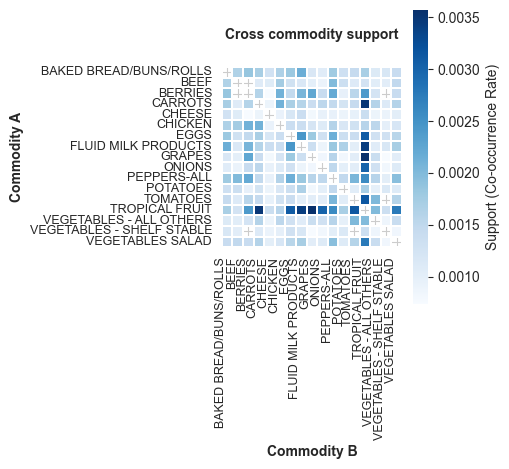


Matrix coverage: 92.0% of cells have data


In [36]:
# Exclude same-commodity pairs
cross_commodity_affinity_support = commodity_affinity[commodity_affinity['COMMODITY_DESC_A'] != commodity_affinity['COMMODITY_DESC_B']]

# Get top commodities by total pair count (use same commodities as lift heatmap for consistency)
top_commodities_a = cross_commodity_affinity_support.groupby('COMMODITY_DESC_A')['pair_count'].sum().nlargest(40).index
top_commodities_b = cross_commodity_affinity_support.groupby('COMMODITY_DESC_B')['pair_count'].sum().nlargest(40).index
top_commodities = sorted(list(set(top_commodities_a) | set(top_commodities_b)))

print(f"Top {len(top_commodities)} commodities selected")

# Filter for top commodities
top_commodity_affinity_support = cross_commodity_affinity_support[
    cross_commodity_affinity_support['COMMODITY_DESC_A'].isin(top_commodities) &
    cross_commodity_affinity_support['COMMODITY_DESC_B'].isin(top_commodities)
]

# Create pivot table - USE NaN FOR MISSING VALUES
commodity_support_matrix = top_commodity_affinity_support.pivot_table(
    index='COMMODITY_DESC_A',
    columns='COMMODITY_DESC_B',
    values='support',
    fill_value=np.nan  # Critical: use NaN not 0
)

# Reindex to make square matrix
commodity_support_matrix = commodity_support_matrix.reindex(
    index=top_commodities,
    columns=top_commodities,
    fill_value=np.nan
)

# Make symmetric while preserving single-direction data
commodity_support_matrix_sym = commodity_support_matrix.copy()

for i in range(len(top_commodities)):
    for j in range(len(top_commodities)):
        val_ij = commodity_support_matrix.iloc[i, j]
        val_ji = commodity_support_matrix.iloc[j, i]
        
        if pd.notna(val_ij) and pd.notna(val_ji):
            # Both exist: average them
            commodity_support_matrix_sym.iloc[i, j] = (val_ij + val_ji) / 2
        elif pd.notna(val_ij):
            # Only i->j exists: use it
            commodity_support_matrix_sym.iloc[i, j] = val_ij
        elif pd.notna(val_ji):
            # Only j->i exists: use it
            commodity_support_matrix_sym.iloc[i, j] = val_ji
        # else: both NaN, leave as NaN

# Remove sparse commodities for cleaner visualization
threshold = 0.5  # Keep commodities with at least x% data coverage
row_coverage = (~commodity_support_matrix_sym.isna()).sum(axis=1) / len(commodity_support_matrix_sym.columns)
col_coverage = (~commodity_support_matrix_sym.isna()).sum(axis=0) / len(commodity_support_matrix_sym.index)

commodities_to_keep = sorted(list(
    set(commodity_support_matrix_sym.index[row_coverage >= threshold]) &
    set(commodity_support_matrix_sym.columns[col_coverage >= threshold])
))

print(f"Commodities kept (≥{threshold*100:.0f}% coverage): {len(commodities_to_keep)}")

# Filter matrix
commodity_support_matrix_clean = commodity_support_matrix_sym.loc[commodities_to_keep, commodities_to_keep]

# Create heatmap
plt.figure(figsize=(5, 5))
sns.heatmap(
    commodity_support_matrix_clean,
    annot=False,  # Too many cells to annotate
    cmap='Blues',
    cbar_kws={'label': 'Support (Co-occurrence Rate)'},
    linewidths=0.1,
    square=True,
    mask=commodity_support_matrix_clean.isna()  # Mask NaN values
)
plt.title('Cross commodity support', fontsize=10, fontweight='bold', pad=20)
plt.xlabel('Commodity B', fontsize=10, fontweight='bold')
plt.ylabel('Commodity A', fontsize=10, fontweight='bold')
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nMatrix coverage: {(~commodity_support_matrix_clean.isna()).sum().sum() / (len(commodities_to_keep)**2) * 100:.1f}% of cells have data")

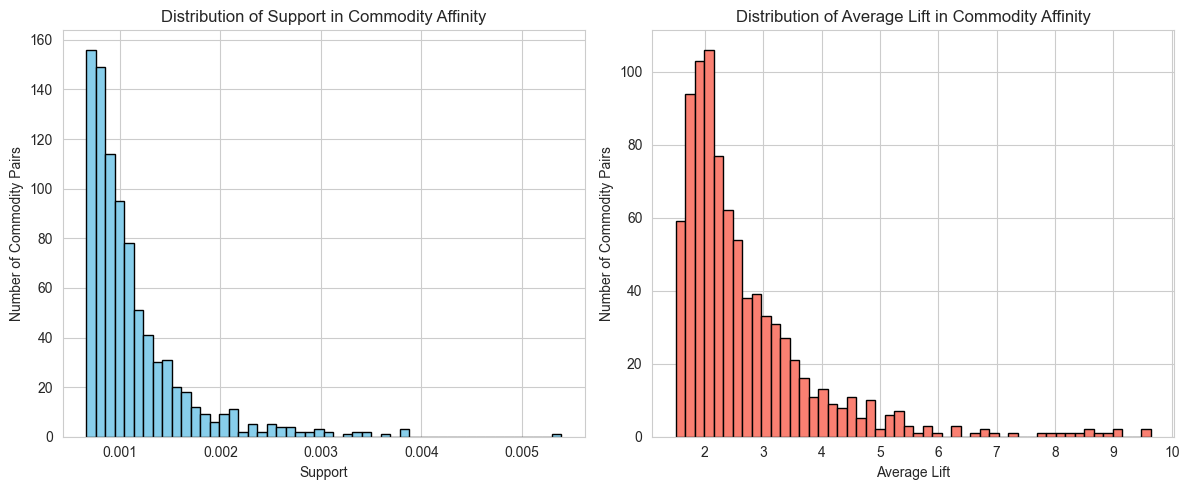

In [37]:
# plot distribution of support and affinity in top_commodity_affinity
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(commodity_affinity['support'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Support in Commodity Affinity')
plt.xlabel('Support')
plt.ylabel('Number of Commodity Pairs')
plt.subplot(1, 2, 2)
plt.hist(commodity_affinity['avg_lift'], bins=50, color='salmon', edgecolor='black')
plt.title('Distribution of Average Lift in Commodity Affinity')
plt.xlabel('Average Lift')
plt.ylabel('Number of Commodity Pairs')
plt.tight_layout()
plt.show()

In [38]:
# Unexpected affinities: High lift but low support
# These represent strong relationships that aren't being fully exploited

# Calculate opportunity score
cross_commodity_affinity['opportunity_score'] = (
    cross_commodity_affinity['avg_lift'] * 
    (1 / (cross_commodity_affinity['support'] + 0.1))  # Inverse support for "hidden" patterns, add 0.1 for readability
)

# Filter for meaningful lift but relatively low support
unexpected = cross_commodity_affinity[
    (cross_commodity_affinity['avg_lift'] > 2.5) &  # Strong affinity
    (cross_commodity_affinity['support'] < 0.001) &  # Low frequency (opportunity)
    (cross_commodity_affinity['pair_count'] > 100)  & # Enough evidence
    (cross_commodity_affinity.COMMODITY_DESC_A.isin(commodities_to_keep))&
    (cross_commodity_affinity.COMMODITY_DESC_B.isin(commodities_to_keep))
].sort_values('opportunity_score', ascending=False)

print("Unexpected High-Affinity Opportunities:")
print("=" * 80)
display(unexpected[[
    'COMMODITY_DESC_A', 'COMMODITY_DESC_B',
    'pair_count', 'support', 'avg_lift', 'opportunity_score'
]].head(20))

Unexpected High-Affinity Opportunities:


,COMMODITY_DESC_A,COMMODITY_DESC_B,pair_count,support,avg_lift,opportunity_score
609,POTATOES,VEGETABLES - ALL OTHERS,538,0.000895,4.485894,44.460907
610,POTATOES,VEGETABLES - SHELF STABLE,448,0.000994,4.183935,41.427565
545,ONIONS,VEGETABLES - SHELF STABLE,124,0.000825,3.415695,33.877338
582,PEPPERS-ALL,VEGETABLES - SHELF STABLE,243,0.000809,3.323933,32.972670
702,TOMATOES,ONIONS,425,0.000943,3.181806,31.520834
611,POTATOES,VEGETABLES SALAD,441,0.000978,3.101252,30.712021
824,VEGETABLES - SHELF STABLE,CHEESE,237,0.000789,3.070833,30.468008
822,VEGETABLES - SHELF STABLE,BEEF,299,0.000995,3.006880,29.772536
161,CARROTS,GRAPES,102,0.000679,2.867580,28.482422
178,CARROTS,VEGETABLES SALAD,276,0.000919,2.848681,28.227530


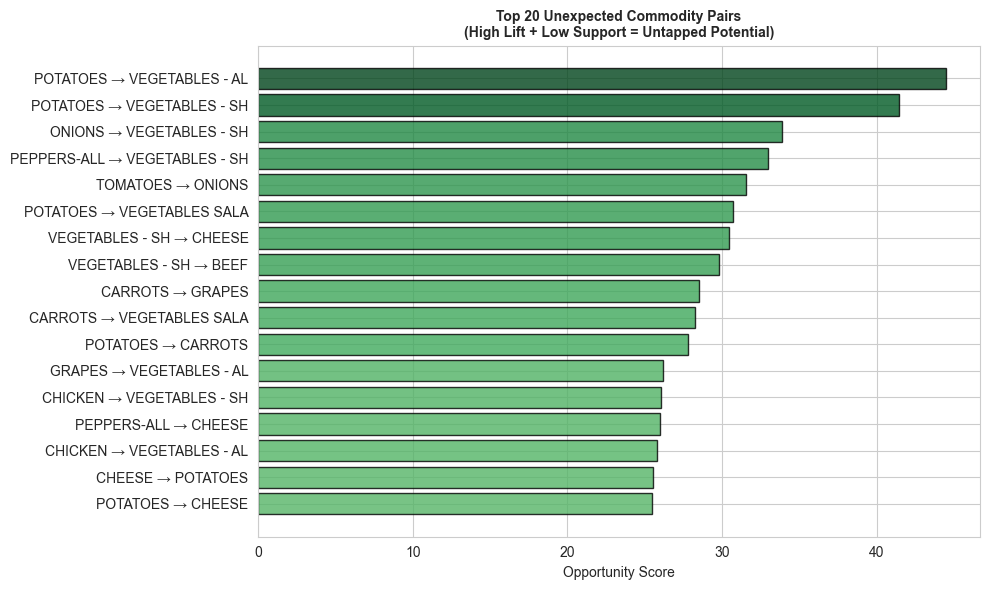

In [39]:
# -----------------------------------------------------------------------------
# Visualise top unexpected pairs by opportunity score
# -----------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 6))

# Get top 25 pairs by opportunity score
top_unexpected = unexpected.nlargest(20, 'opportunity_score').sort_values('opportunity_score', ascending=True)

# Create labels
labels = top_unexpected['COMMODITY_DESC_A'].str[:15] + ' → ' + top_unexpected['COMMODITY_DESC_B'].str[:15]

# Color by lift (higher lift = darker green)
colors = plt.cm.Greens(top_unexpected['avg_lift'] / top_unexpected['avg_lift'].max())

bars = ax.barh(labels, top_unexpected['opportunity_score'], color=colors, edgecolor='black', alpha=0.8)

ax.set_xlabel('Opportunity Score', fontsize=10)
ax.set_title('Top 20 Unexpected Commodity Pairs\n(High Lift + Low Support = Untapped Potential)', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [40]:
# COMMODITY-LEVEL ANCHOR ANALYSIS
# Identify commodities that drive high cross-commodity purchases

# Count distinct commodities purchased with each commodity
commodity_cross_a = cross_commodity_affinity.groupby('COMMODITY_DESC_A').agg({
    'COMMODITY_DESC_B': 'count',  # Number of other commodities it pairs with
    'pair_count': 'sum',          # Total cross-commodity pairs
    'avg_lift': 'mean'            # Average lift across all pairings
}).reset_index()

commodity_cross_a.columns = ['COMMODITY_DESC', 'commodity_connections', 'total_cross_pairs', 'avg_cross_lift']

# Also get the same for COMMODITY_DESC_B
commodity_cross_b = cross_commodity_affinity.groupby('COMMODITY_DESC_B').agg({
    'COMMODITY_DESC_A': 'count',
    'pair_count': 'sum',
    'avg_lift': 'mean'
}).reset_index()

commodity_cross_b.columns = ['COMMODITY_DESC', 'commodity_connections', 'total_cross_pairs', 'avg_cross_lift']

# Combine and aggregate
commodity_anchor_metrics = pd.concat([commodity_cross_a, commodity_cross_b]).groupby('COMMODITY_DESC').agg({
    'commodity_connections': 'sum',
    'total_cross_pairs': 'sum',
    'avg_cross_lift': 'mean'
}).reset_index()

# Calculate anchor score (combination of connectivity and lift)
commodity_anchor_metrics['anchor_score'] = (
    (commodity_anchor_metrics['commodity_connections'] / commodity_anchor_metrics['commodity_connections'].max()) * 0.3 +
    (commodity_anchor_metrics['total_cross_pairs'] / commodity_anchor_metrics['total_cross_pairs'].max()) * 0.4 +
    (commodity_anchor_metrics['avg_cross_lift'] / commodity_anchor_metrics['avg_cross_lift'].max()) * 0.3
) * 100

commodity_anchor_metrics = commodity_anchor_metrics.sort_values('anchor_score', ascending=False)

print("Top 15 Anchor Commodities (Drive Cross-Commodity Purchases):")
print("=" * 80)
display(commodity_anchor_metrics.head(15))

Top 15 Anchor Commodities (Drive Cross-Commodity Purchases):


,COMMODITY_DESC,commodity_connections,total_cross_pairs,avg_cross_lift,anchor_score
103,TROPICAL FRUIT,164,178148,2.052524,81.529472
45,FLUID MILK PRODUCTS,110,129064,2.077980,60.773464
3,BAKED BREAD/BUNS/ROLLS,92,91430,2.786153,53.008688
41,EGGS,89,70224,2.139379,44.065408
107,VEGETABLES - ALL OTHERS,56,35220,3.116175,35.656161
20,CHEESE,50,40651,2.627660,33.033943
75,ONIONS,44,28031,3.151458,32.045070
102,TOMATOES,50,27851,2.792645,31.086681
81,PEPPERS-ALL,51,23215,2.925959,30.977530
67,MEAT - MISC,5,2203,5.214178,30.698440


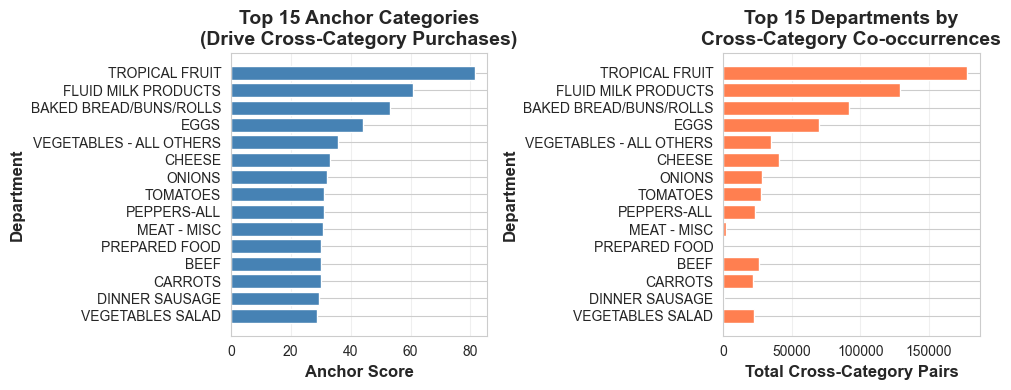


✓ Saved: anchor_categories.png


In [41]:
# Create bar chart of top anchor categories
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Anchor Score
top_anchors = commodity_anchor_metrics.head(15)
axes[0].barh(top_anchors['COMMODITY_DESC'], top_anchors['anchor_score'], color='steelblue')
axes[0].set_xlabel('Anchor Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Department', fontsize=12, fontweight='bold')
axes[0].set_title('Top 15 Anchor Categories\n(Drive Cross-Category Purchases)', 
                  fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Total Cross-Category Pairs
axes[1].barh(top_anchors['COMMODITY_DESC'], top_anchors['total_cross_pairs'], color='coral')
axes[1].set_xlabel('Total Cross-Category Pairs', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Department', fontsize=12, fontweight='bold')
axes[1].set_title('Top 15 Departments by\nCross-Category Co-occurrences', 
                  fontsize=14, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('anchor_categories.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: anchor_categories.png")

In [42]:
# =============================================================================
# TASK 4: PROMOTIONAL IMPACT ON AFFINITIES
# Step 4.1: Join causal_data with transaction_data to identify promoted products
# =============================================================================

# Step 4.1.1: Identify all relevant departments and commodities for analysis

# Get top 3 anchor departments and their top 5 partners
top_anchor_depts = anchor_metrics.head(3)['DEPARTMENT'].tolist()

dept_partners = []
for dept in top_anchor_depts:
    partners = cross_dept_affinity[
        (cross_dept_affinity['DEPARTMENT_A'] == dept) |
        (cross_dept_affinity['DEPARTMENT_B'] == dept)
    ].nlargest(5, 'avg_lift')
    
    for _, row in partners.iterrows():
        partner = row['DEPARTMENT_B'] if row['DEPARTMENT_A'] == dept else row['DEPARTMENT_A']
        dept_partners.append(partner)

relevant_departments = set(top_anchor_depts + dept_partners)
print(f"Relevant departments: {len(relevant_departments)}")
print(relevant_departments)

# Get top 3 anchor commodities and their top 5 partners
top_anchor_commodities = commodity_anchor_metrics.head(3)['COMMODITY_DESC'].tolist()

commodity_partners = []
for comm in top_anchor_commodities:
    partners = cross_commodity_affinity[
        (cross_commodity_affinity['COMMODITY_DESC_A'] == comm) |
        (cross_commodity_affinity['COMMODITY_DESC_B'] == comm)
    ].nlargest(5, 'avg_lift')
    
    for _, row in partners.iterrows():
        partner = row['COMMODITY_DESC_B'] if row['COMMODITY_DESC_A'] == comm else row['COMMODITY_DESC_A']
        commodity_partners.append(partner)

relevant_commodities = set(top_anchor_commodities + commodity_partners)
print(f"\nRelevant commodities: {len(relevant_commodities)}")
print(relevant_commodities)

Relevant departments: 10
{'PASTRY', 'MEAT-PCKGD', 'MISC. TRANS.', 'NUTRITION', 'TRAVEL & LEISUR', 'PRODUCE', 'SEAFOOD-PCKGD', 'GROCERY', 'DELI', 'SALAD BAR'}

Relevant commodities: 16
{'BROCCOLI/CAULIFLOWER', 'HOT DOGS', 'REFRGRATD JUICES/DRNKS', 'COCOA MIXES', 'MEAT - MISC', 'TOMATOES', 'HERBS', 'FLUID MILK PRODUCTS', 'BEANS - CANNED GLASS & MW', 'DINNER SAUSAGE', 'REFRGRATD DOUGH PRODUCTS', 'TROPICAL FRUIT', 'BAKED BREAD/BUNS/ROLLS', 'BERRIES', 'MISC. DAIRY', 'PEARS'}


In [43]:
# Step 4.1.2: Filter transactions to meaningful baskets and relevant categories

# Get basket IDs from meaningful_baskets (already filtered for 3+ items)
meaningful_basket_ids = meaningful_baskets['BASKET_ID'].unique()
print(f"Meaningful baskets: {len(meaningful_basket_ids):,}")

# Filter transaction_data to meaningful baskets only
transactions_filtered = transaction_data[
    transaction_data['BASKET_ID'].isin(meaningful_basket_ids)
].copy()
print(f"Transactions in meaningful baskets: {len(transactions_filtered):,} (from {len(transaction_data):,})")

# Add product metadata to identify department/commodity
transactions_filtered = transactions_filtered.merge(
    product_data[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='left'
)

# Filter to relevant departments OR relevant commodities
transactions_filtered = transactions_filtered[
    (transactions_filtered['DEPARTMENT'].isin(relevant_departments)) |
    (transactions_filtered['COMMODITY_DESC'].isin(relevant_commodities))
]

print(f"Transactions in relevant categories: {len(transactions_filtered):,}")

Meaningful baskets: 150,237
Transactions in meaningful baskets: 2,337,070 (from 2,595,732)
Transactions in relevant categories: 1,995,752


In [44]:
# Step 4.1.3: Load causal_data and merge with filtered transactions

# Load causal data
causal_data = pd.read_csv('causal_data.csv')
causal_data.columns = causal_data.columns.str.upper()

print(f"Causal data shape: {causal_data.shape}")

# Merge with filtered transactions
transactions_with_promo = transactions_filtered.merge(
    causal_data,
    on=['PRODUCT_ID', 'STORE_ID', 'WEEK_NO'],
    how='left'
)

print(f"\nFiltered transactions: {len(transactions_filtered):,}")
print(f"After merge with causal_data: {len(transactions_with_promo):,}")

# Check coverage
has_promo_data = transactions_with_promo['DISPLAY'].notna()
print(f"\nTransactions with promotional data: {has_promo_data.sum():,} ({has_promo_data.mean()*100:.1f}%)")
print(f"Transactions without promotional data: {(~has_promo_data).sum():,} ({(~has_promo_data).mean()*100:.1f}%)")

Causal data shape: (36786524, 5)

Filtered transactions: 1,995,752
After merge with causal_data: 1,996,108

Transactions with promotional data: 452,359 (22.7%)
Transactions without promotional data: 1,543,749 (77.3%)


In [45]:
len(transactions_with_promo[(transactions_with_promo.MAILER=='0')&(transactions_with_promo.DISPLAY=='0')])

0

In [46]:
# Step 4.1.4: Create promotion flags
# NaN means not in causal_data, which means not promoted

# Fill NaN with "not promoted" values
# Safe to do this because there are no values in transactions_with_promo for DISPLAY or MAILER that are '0' originally
transactions_with_promo['DISPLAY'] = transactions_with_promo['DISPLAY'].fillna('0')
transactions_with_promo['MAILER'] = transactions_with_promo['MAILER'].fillna('0')

# Create promotion flags
transactions_with_promo['is_displayed'] = transactions_with_promo['DISPLAY'] !='0'
transactions_with_promo['is_in_mailer'] = transactions_with_promo['MAILER'] != '0'
transactions_with_promo['is_promoted'] = (
    transactions_with_promo['is_displayed'] | transactions_with_promo['is_in_mailer']
)

# Summary
print("Promotion breakdown:")
print(f"On display: {transactions_with_promo['is_displayed'].sum():,} ({transactions_with_promo['is_displayed'].mean()*100:.1f}%)")
print(f"In mailer: {transactions_with_promo['is_in_mailer'].sum():,} ({transactions_with_promo['is_in_mailer'].mean()*100:.1f}%)")
print(f"Any promotion: {transactions_with_promo['is_promoted'].sum():,} ({transactions_with_promo['is_promoted'].mean()*100:.1f}%)")
print(f"Not promoted: {(~transactions_with_promo['is_promoted']).sum():,} ({(~transactions_with_promo['is_promoted']).mean()*100:.1f}%)")

print("\nSample of transactions_with_promo:")
display(transactions_with_promo[['BASKET_ID', 'PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC', 
                                  'DISPLAY', 'MAILER', 'is_promoted', 'SALES_VALUE']].head(10))

Promotion breakdown:
On display: 228,687 (11.5%)
In mailer: 332,249 (16.6%)
Any promotion: 452,359 (22.7%)
Not promoted: 1,543,749 (77.3%)

Sample of transactions_with_promo:


,BASKET_ID,PRODUCT_ID,DEPARTMENT,COMMODITY_DESC,DISPLAY,MAILER,is_promoted,SALES_VALUE
0,26984851516,826249,GROCERY,BAKED BREAD/BUNS/ROLLS,0,0,False,1.98
1,26984851516,1085983,GROCERY,COOKIES/CONES,0,0,False,2.99
2,26984851516,1102651,GROCERY,PNT BTR/JELLY/JAMS,0,0,False,1.89
3,26984851516,6423775,GROCERY,COOKIES/CONES,0,0,False,2.00
4,26984851516,9487839,GROCERY,COOKIES/CONES,0,0,False,2.00
5,26984896261,842930,GROCERY,CONVENIENT BRKFST/WHLSM SNACKS,0,0,False,2.19
6,26984896261,897044,GROCERY,CRACKERS/MISC BKD FD,0,0,False,2.99
7,26984896261,937406,MEAT-PCKGD,BREAKFAST SAUSAGE/SANDWICHES,0,0,False,2.50
8,26984896261,981760,GROCERY,EGGS,0,0,False,0.60
9,26985025264,930917,GROCERY,MEAT - SHELF STABLE,0,0,False,2.00


In [47]:
# =============================================================================
# TASK 4.2: ANALYSE IF PROMOTIONS ON ANCHOR CATEGORIES INCREASE 
#           PURCHASES OF HIGH-AFFINITY PARTNERS
# =============================================================================


# PART A: DEPARTMENT-LEVEL ANALYSIS

# Build anchor-partner lookup with affinity lift

def get_top_partners_dept(anchor_dept, n=5):
    """Get top n affinity partners for a department"""
    partners = cross_dept_affinity[
        (cross_dept_affinity['DEPARTMENT_A'] == anchor_dept) |
        (cross_dept_affinity['DEPARTMENT_B'] == anchor_dept)
    ].copy()
    
    partners['ANCHOR'] = anchor_dept
    partners['PARTNER'] = partners.apply(
        lambda row: row['DEPARTMENT_B'] if row['DEPARTMENT_A'] == anchor_dept else row['DEPARTMENT_A'],
        axis=1
    )
    
    return partners.nlargest(n, 'avg_lift')[['ANCHOR', 'PARTNER', 'avg_lift']]

dept_anchor_partners = pd.concat([
    get_top_partners_dept(dept) for dept in top_anchor_depts
]).reset_index(drop=True)

print("Top 10 Anchor Departments and their Top 5 Partners:")
print("=" * 80)
display(dept_anchor_partners)

Top 10 Anchor Departments and their Top 5 Partners:


,ANCHOR,PARTNER,avg_lift
0,GROCERY,NUTRITION,4.917921
1,GROCERY,TRAVEL & LEISUR,4.351269
2,GROCERY,SEAFOOD-PCKGD,3.711801
3,GROCERY,NUTRITION,3.573092
4,GROCERY,MEAT-PCKGD,3.426305
5,PRODUCE,TRAVEL & LEISUR,3.845700
6,PRODUCE,MISC. TRANS.,3.513609
7,PRODUCE,NUTRITION,3.091835
8,PRODUCE,MISC. TRANS.,3.008363
9,PRODUCE,SEAFOOD-PCKGD,2.734248


In [48]:
# Create basket-level summary with promotion status per department

basket_dept_promo = transactions_with_promo[transactions_with_promo.DEPARTMENT.isin(relevant_departments)].groupby(['BASKET_ID', 'DEPARTMENT']).agg({
    'is_promoted': lambda x: True if x.any() == True else (False if (x == False).any() else np.nan),
    'PRODUCT_ID': 'count'
}).reset_index()

basket_dept_promo.columns = ['BASKET_ID', 'DEPARTMENT', 'dept_promoted', 'product_count']

print(f"Basket-department combinations: {len(basket_dept_promo):,}")
print(f"With known promotion status: {basket_dept_promo['dept_promoted'].notna().sum():,}")
print(f"  - Promoted: {(basket_dept_promo['dept_promoted'] == True).sum():,}")
print(f"  - Not promoted: {(basket_dept_promo['dept_promoted'] == False).sum():,}")

Basket-department combinations: 362,148
With known promotion status: 362,148
  - Promoted: 170,183
  - Not promoted: 191,965


In [49]:
dept_anchor_partners

,ANCHOR,PARTNER,avg_lift
0,GROCERY,NUTRITION,4.917921
1,GROCERY,TRAVEL & LEISUR,4.351269
2,GROCERY,SEAFOOD-PCKGD,3.711801
3,GROCERY,NUTRITION,3.573092
4,GROCERY,MEAT-PCKGD,3.426305
5,PRODUCE,TRAVEL & LEISUR,3.845700
6,PRODUCE,MISC. TRANS.,3.513609
7,PRODUCE,NUTRITION,3.091835
8,PRODUCE,MISC. TRANS.,3.008363
9,PRODUCE,SEAFOOD-PCKGD,2.734248


In [50]:
# Calculate promotion lift for each anchor-partner pair (Department Level)

dept_promo_lift_results = []

for _, row in dept_anchor_partners.iterrows():
    anchor = row['ANCHOR']
    partner = row['PARTNER']
    baseline_lift = row['avg_lift']
    
    # Find baskets containing the anchor with KNOWN promotion status
    anchor_baskets = basket_dept_promo[
        (basket_dept_promo['DEPARTMENT'] == anchor) & 
        (basket_dept_promo['dept_promoted'].notna())
    ][['BASKET_ID', 'dept_promoted']].copy()
    anchor_baskets.columns = ['BASKET_ID', 'anchor_promoted']
    
    # Find baskets containing the partner
    partner_baskets = basket_dept_promo[
        basket_dept_promo['DEPARTMENT'] == partner
    ]['BASKET_ID'].unique()
    
    # Flag whether each anchor basket also contains the partner
    anchor_baskets['has_partner'] = anchor_baskets['BASKET_ID'].isin(partner_baskets)
    
    # Split by promotion status
    promoted = anchor_baskets[anchor_baskets['anchor_promoted'] == True]
    not_promoted = anchor_baskets[anchor_baskets['anchor_promoted'] == False]
    
    # Calculate partner purchase rates
    n_promoted = len(promoted)
    n_not_promoted = len(not_promoted)
    
    if n_promoted > 0 and n_not_promoted > 0:
        partner_rate_promoted = promoted['has_partner'].mean()
        partner_rate_not_promoted = not_promoted['has_partner'].mean()
        
        # Calculate promotion lift (avoid division by zero)
        if partner_rate_not_promoted > 0:
            promo_lift = partner_rate_promoted / partner_rate_not_promoted
        else:
            promo_lift = np.nan
        
        dept_promo_lift_results.append({
            'anchor_dept': anchor,
            'partner_dept': partner,
            'baseline_affinity_lift': baseline_lift,
            'n_baskets_promoted': n_promoted,
            'n_baskets_not_promoted': n_not_promoted,
            'partner_rate_when_promoted': partner_rate_promoted,
            'partner_rate_when_not_promoted': partner_rate_not_promoted,
            'promotion_lift': promo_lift
        })

dept_promo_lift_df = pd.DataFrame(dept_promo_lift_results)

print("=" * 100)
print("DEPARTMENT-LEVEL: PROMOTION IMPACT ON AFFINITY PARTNER PURCHASES")
print("=" * 100)
print("\nPromotion Lift > 1 means promoting the anchor increases partner purchases\n")
display(dept_promo_lift_df.sort_values('promotion_lift', ascending=False))

DEPARTMENT-LEVEL: PROMOTION IMPACT ON AFFINITY PARTNER PURCHASES

Promotion Lift > 1 means promoting the anchor increases partner purchases



,anchor_dept,partner_dept,baseline_affinity_lift,n_baskets_promoted,n_baskets_not_promoted,partner_rate_when_promoted,partner_rate_when_not_promoted,promotion_lift
4,GROCERY,MEAT-PCKGD,3.426305,100896,43568,0.430542,0.222090,1.938597
1,GROCERY,TRAVEL & LEISUR,4.351269,100896,43568,0.006373,0.003512,1.814735
2,GROCERY,SEAFOOD-PCKGD,3.711801,100896,43568,0.066425,0.037390,1.776548
7,PRODUCE,NUTRITION,3.091835,26525,52119,0.178172,0.129953,1.371050
5,PRODUCE,TRAVEL & LEISUR,3.845700,26525,52119,0.010631,0.007905,1.344908
9,PRODUCE,SEAFOOD-PCKGD,2.734248,26525,52119,0.092592,0.071586,1.293433
0,GROCERY,NUTRITION,4.917921,100896,43568,0.102591,0.087840,1.167932
3,GROCERY,NUTRITION,3.573092,100896,43568,0.102591,0.087840,1.167932
6,PRODUCE,MISC. TRANS.,3.513609,26525,52119,0.017531,0.015426,1.136417
8,PRODUCE,MISC. TRANS.,3.008363,26525,52119,0.017531,0.015426,1.136417


In [51]:
# PART B: COMMODITY-LEVEL ANALYSIS

# Build anchor-partner lookup
# (Reusing top_anchor_commodities from step 4.1.1)

def get_top_partners_commodity(anchor_commodity, n=5):
    """Get top n affinity partners for a commodity"""
    partners = cross_commodity_affinity[
        (cross_commodity_affinity['COMMODITY_DESC_A'] == anchor_commodity) |
        (cross_commodity_affinity['COMMODITY_DESC_B'] == anchor_commodity)
    ].copy()
    
    partners['ANCHOR'] = anchor_commodity
    partners['PARTNER'] = partners.apply(
        lambda row: row['COMMODITY_DESC_B'] if row['COMMODITY_DESC_A'] == anchor_commodity else row['COMMODITY_DESC_A'],
        axis=1
    )
    
    return partners.nlargest(n, 'avg_lift')[['ANCHOR', 'PARTNER', 'avg_lift']]

commodity_anchor_partners = pd.concat([
    get_top_partners_commodity(comm) for comm in top_anchor_commodities
]).reset_index(drop=True)

print("Top 10 Anchor Commodities and their Top 5 Partners:")
print("=" * 80)
display(commodity_anchor_partners)

Top 10 Anchor Commodities and their Top 5 Partners:


,ANCHOR,PARTNER,avg_lift
0,TROPICAL FRUIT,HERBS,5.035523
1,TROPICAL FRUIT,TOMATOES,3.595889
2,TROPICAL FRUIT,BERRIES,3.233782
3,TROPICAL FRUIT,PEARS,3.156924
4,TROPICAL FRUIT,MISC. DAIRY,3.149298
5,FLUID MILK PRODUCTS,REFRGRATD JUICES/DRNKS,3.722616
6,FLUID MILK PRODUCTS,REFRGRATD JUICES/DRNKS,3.388809
7,FLUID MILK PRODUCTS,COCOA MIXES,3.127181
8,FLUID MILK PRODUCTS,REFRGRATD DOUGH PRODUCTS,2.951517
9,FLUID MILK PRODUCTS,BROCCOLI/CAULIFLOWER,2.940209


In [52]:
# Create basket-level summary with promotion status per commodity

basket_commodity_promo = transactions_with_promo[transactions_with_promo.COMMODITY_DESC.isin(relevant_commodities)].groupby(['BASKET_ID', 'COMMODITY_DESC']).agg({
    'is_promoted': lambda x: True if x.any() == True else (False if (x == False).any() else np.nan),
    'PRODUCT_ID': 'count'
}).reset_index()

basket_commodity_promo.columns = ['BASKET_ID', 'COMMODITY_DESC', 'commodity_promoted', 'product_count']

print(f"Basket-commodity combinations: {len(basket_commodity_promo):,}")
print(f"With known promotion status: {basket_commodity_promo['commodity_promoted'].notna().sum():,}")
print(f"  - Promoted: {(basket_commodity_promo['commodity_promoted'] == True).sum():,}")
print(f"  - Not promoted: {(basket_commodity_promo['commodity_promoted'] == False).sum():,}")

Basket-commodity combinations: 258,771
With known promotion status: 258,771
  - Promoted: 85,596
  - Not promoted: 173,175


In [53]:
# Calculate promotion lift for each anchor-partner pair (Commodity Level)

commodity_promo_lift_results = []

for _, row in commodity_anchor_partners.iterrows():
    anchor = row['ANCHOR']
    partner = row['PARTNER']
    baseline_lift = row['avg_lift']
    
    # Find baskets containing the anchor with KNOWN promotion status
    anchor_baskets = basket_commodity_promo[
        (basket_commodity_promo['COMMODITY_DESC'] == anchor) & 
        (basket_commodity_promo['commodity_promoted'].notna())
    ][['BASKET_ID', 'commodity_promoted']].copy()
    anchor_baskets.columns = ['BASKET_ID', 'anchor_promoted']
    
    # Find baskets containing the partner
    partner_baskets = basket_commodity_promo[
        basket_commodity_promo['COMMODITY_DESC'] == partner
    ]['BASKET_ID'].unique()
    
    # Flag whether each anchor basket also contains the partner
    anchor_baskets['has_partner'] = anchor_baskets['BASKET_ID'].isin(partner_baskets)
    
    # Split by promotion status
    promoted = anchor_baskets[anchor_baskets['anchor_promoted'] == True]
    not_promoted = anchor_baskets[anchor_baskets['anchor_promoted'] == False]
    
    # Calculate partner purchase rates
    n_promoted = len(promoted)
    n_not_promoted = len(not_promoted)
    
    if n_promoted > 0 and n_not_promoted > 0:
        partner_rate_promoted = promoted['has_partner'].mean()
        partner_rate_not_promoted = not_promoted['has_partner'].mean()
        
        if partner_rate_not_promoted > 0:
            promo_lift = partner_rate_promoted / partner_rate_not_promoted
        else:
            promo_lift = np.nan
        
        commodity_promo_lift_results.append({
            'anchor_commodity': anchor,
            'partner_commodity': partner,
            'baseline_affinity_lift': baseline_lift,
            'n_baskets_promoted': n_promoted,
            'n_baskets_not_promoted': n_not_promoted,
            'partner_rate_when_promoted': partner_rate_promoted,
            'partner_rate_when_not_promoted': partner_rate_not_promoted,
            'promotion_lift': promo_lift
        })

commodity_promo_lift_df = pd.DataFrame(commodity_promo_lift_results)

print("=" * 100)
print("COMMODITY-LEVEL: PROMOTION IMPACT ON AFFINITY PARTNER PURCHASES")
print("=" * 100)
print("\nPromotion Lift > 1 means promoting the anchor increases partner purchases\n")
display(commodity_promo_lift_df.sort_values('promotion_lift', ascending=False))

COMMODITY-LEVEL: PROMOTION IMPACT ON AFFINITY PARTNER PURCHASES

Promotion Lift > 1 means promoting the anchor increases partner purchases



,anchor_commodity,partner_commodity,baseline_affinity_lift,n_baskets_promoted,n_baskets_not_promoted,partner_rate_when_promoted,partner_rate_when_not_promoted,promotion_lift
12,BAKED BREAD/BUNS/ROLLS,HOT DOGS,6.816925,21671,32021,0.184025,0.108241,1.700132
11,BAKED BREAD/BUNS/ROLLS,MEAT - MISC,7.831185,21671,32021,0.114762,0.076419,1.501750
14,BAKED BREAD/BUNS/ROLLS,MEAT - MISC,4.527069,21671,32021,0.114762,0.076419,1.501750
10,BAKED BREAD/BUNS/ROLLS,DINNER SAUSAGE,8.548336,21671,32021,0.127359,0.094657,1.345486
13,BAKED BREAD/BUNS/ROLLS,BEANS - CANNED GLASS & MW,5.400557,21671,32021,0.113423,0.090847,1.248516
5,FLUID MILK PRODUCTS,REFRGRATD JUICES/DRNKS,3.722616,27008,32229,0.260219,0.222160,1.171313
6,FLUID MILK PRODUCTS,REFRGRATD JUICES/DRNKS,3.388809,27008,32229,0.260219,0.222160,1.171313
8,FLUID MILK PRODUCTS,REFRGRATD DOUGH PRODUCTS,2.951517,27008,32229,0.142254,0.126966,1.120408
0,TROPICAL FRUIT,HERBS,5.035523,5360,24399,0.044216,0.040002,1.105365
7,FLUID MILK PRODUCTS,COCOA MIXES,3.127181,27008,32229,0.040840,0.037637,1.085098


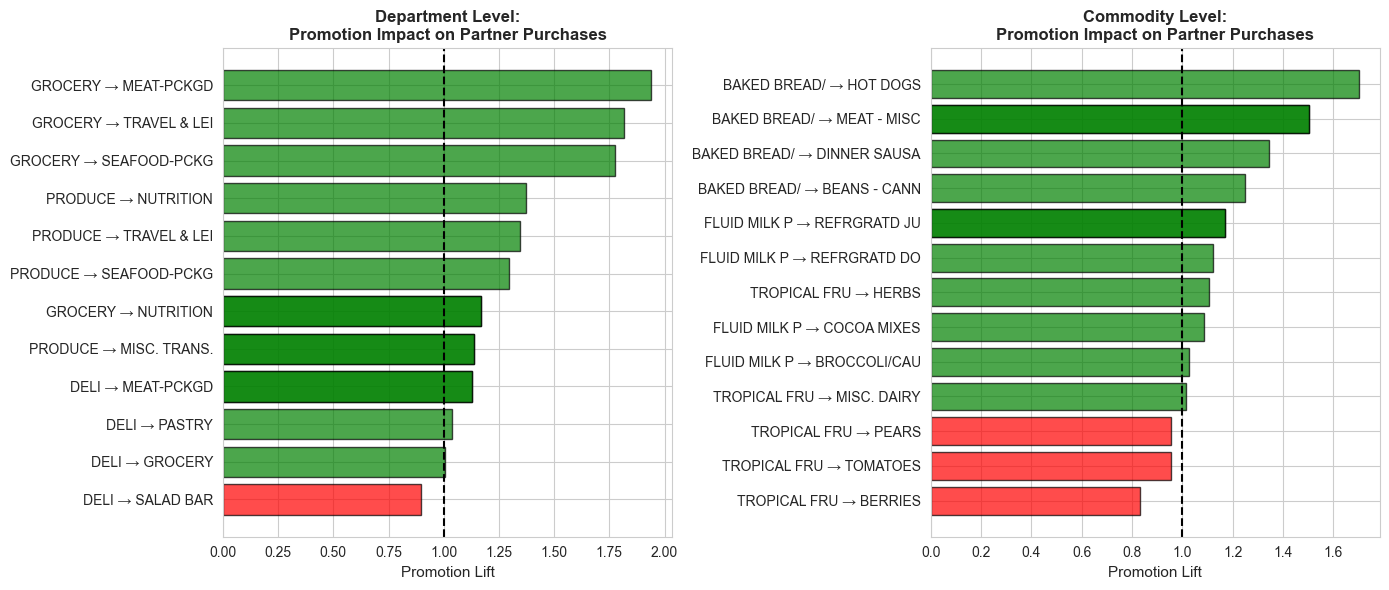

In [54]:
# Visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Department level
ax1 = axes[0]
dept_plot = dept_promo_lift_df.dropna(subset=['promotion_lift']).sort_values('promotion_lift', ascending=True)
colors = ['green' if x > 1 else 'red' for x in dept_plot['promotion_lift']]
labels = dept_plot['anchor_dept'].str[:12] + ' → ' + dept_plot['partner_dept'].str[:12]
ax1.barh(labels, dept_plot['promotion_lift'], color=colors, edgecolor='black', alpha=0.7)
ax1.axvline(x=1, color='black', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Promotion Lift', fontsize=11)
ax1.set_title('Department Level:\nPromotion Impact on Partner Purchases', fontsize=12, fontweight='bold')

# Commodity level (show top 20 for readability)
ax2 = axes[1]
commodity_plot = commodity_promo_lift_df.dropna(subset=['promotion_lift']).sort_values('promotion_lift', ascending=True).tail(25)
colors = ['green' if x > 1 else 'red' for x in commodity_plot['promotion_lift']]
labels = commodity_plot['anchor_commodity'].str[:12] + ' → ' + commodity_plot['partner_commodity'].str[:12]
ax2.barh(labels, commodity_plot['promotion_lift'], color=colors, edgecolor='black', alpha=0.7)
ax2.axvline(x=1, color='black', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Promotion Lift', fontsize=11)
ax2.set_title('Commodity Level:\nPromotion Impact on Partner Purchases', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [55]:
# =============================================================================
# TASK 4.3: CALCULATE HALO EFFECT (Commodity Level)
# Incremental revenue from affinity products when anchor is promoted
# =============================================================================


# Step 4.3.1: Get total sales per basket per commodity

basket_commodity_sales = transactions_with_promo.groupby(['BASKET_ID', 'COMMODITY_DESC']).agg({
    'SALES_VALUE': 'sum',
    'is_promoted': lambda x: True if x.any() == True else False
}).reset_index()

basket_commodity_sales.columns = ['BASKET_ID', 'COMMODITY_DESC', 'commodity_sales', 'commodity_promoted']

print(f"Basket-commodity sales records: {len(basket_commodity_sales):,}")

Basket-commodity sales records: 1,436,348


In [56]:
# =============================================================================
# TASK 4.3: CALCULATE HALO EFFECT (Commodity Level)
# Incremental revenue from affinity products when anchor is promoted
# =============================================================================

# Step 4.3.1: Filter transactions to relevant commodities only

# Get relevant commodities (anchors + partners)
relevant_commodities_halo = set(commodity_anchor_partners['ANCHOR'].tolist() + 
                                 commodity_anchor_partners['PARTNER'].tolist())

print(f"Relevant commodities for halo analysis: {len(relevant_commodities_halo)}")

# Filter transactions_with_promo to only include relevant commodities
transactions_halo = transactions_with_promo[
    transactions_with_promo['COMMODITY_DESC'].isin(relevant_commodities_halo)
].copy()

print(f"Transactions in relevant commodities: {len(transactions_halo):,} (from {len(transactions_with_promo):,})")

Relevant commodities for halo analysis: 16
Transactions in relevant commodities: 320,331 (from 1,996,108)


In [57]:
# Step 4.3.2: Get total sales per basket per commodity

basket_commodity_sales = transactions_halo.groupby(['BASKET_ID', 'COMMODITY_DESC']).agg({
    'SALES_VALUE': 'sum',
    'is_promoted': lambda x: True if x.any() == True else False
}).reset_index()

basket_commodity_sales.columns = ['BASKET_ID', 'COMMODITY_DESC', 'commodity_sales', 'commodity_promoted']

print(f"Basket-commodity sales records: {len(basket_commodity_sales):,}")

Basket-commodity sales records: 258,771


In [58]:
# Step 4.3.3: Calculate halo effect for each anchor-partner pair

commodity_halo_results = []

for _, row in commodity_anchor_partners.iterrows():
    anchor = row['ANCHOR']
    partner = row['PARTNER']
    baseline_lift = row['avg_lift']
    
    # Find baskets containing the anchor
    anchor_baskets = basket_commodity_sales[
        basket_commodity_sales['COMMODITY_DESC'] == anchor
    ][['BASKET_ID', 'commodity_promoted']].copy()
    anchor_baskets.columns = ['BASKET_ID', 'anchor_promoted']
    
    # Get partner sales for those baskets
    partner_sales = basket_commodity_sales[
        basket_commodity_sales['COMMODITY_DESC'] == partner
    ][['BASKET_ID', 'commodity_sales']].copy()
    partner_sales.columns = ['BASKET_ID', 'partner_sales']
    
    # Merge
    merged = anchor_baskets.merge(partner_sales, on='BASKET_ID', how='left')
    merged['partner_sales'] = merged['partner_sales'].fillna(0)
    
    # Split by promotion status
    promoted = merged[merged['anchor_promoted'] == True]
    not_promoted = merged[merged['anchor_promoted'] == False]
    
    if len(promoted) > 0 and len(not_promoted) > 0:
        avg_partner_sales_promoted = promoted['partner_sales'].mean()
        avg_partner_sales_not_promoted = not_promoted['partner_sales'].mean()
        
        halo_effect = avg_partner_sales_promoted - avg_partner_sales_not_promoted
        
        if avg_partner_sales_not_promoted > 0:
            halo_pct = (halo_effect / avg_partner_sales_not_promoted) * 100
        else:
            halo_pct = np.nan
        
        total_incremental_revenue = halo_effect * len(promoted)
        
        commodity_halo_results.append({
            'anchor_commodity': anchor,
            'partner_commodity': partner,
            'baseline_affinity_lift': baseline_lift,
            'n_baskets_promoted': len(promoted),
            'n_baskets_not_promoted': len(not_promoted),
            'avg_partner_sales_when_promoted': avg_partner_sales_promoted,
            'avg_partner_sales_when_not_promoted': avg_partner_sales_not_promoted,
            'halo_effect_per_basket': halo_effect,
            'halo_effect_pct': halo_pct,
            'total_incremental_revenue': total_incremental_revenue
        })

commodity_halo_df = pd.DataFrame(commodity_halo_results)

print("=" * 100)
print("COMMODITY-LEVEL: HALO EFFECT (Incremental Partner Revenue)")
print("=" * 100)
print("\nPositive halo = promotion on anchor increases partner sales\n")
display(commodity_halo_df.sort_values('halo_effect_per_basket', ascending=False))

COMMODITY-LEVEL: HALO EFFECT (Incremental Partner Revenue)

Positive halo = promotion on anchor increases partner sales



,anchor_commodity,partner_commodity,baseline_affinity_lift,n_baskets_promoted,n_baskets_not_promoted,avg_partner_sales_when_promoted,avg_partner_sales_when_not_promoted,halo_effect_per_basket,halo_effect_pct,total_incremental_revenue
11,BAKED BREAD/BUNS/ROLLS,MEAT - MISC,7.831185,21671,32021,0.952823,0.603468,0.349355,57.891152,7570.867411
14,BAKED BREAD/BUNS/ROLLS,MEAT - MISC,4.527069,21671,32021,0.952823,0.603468,0.349355,57.891152,7570.867411
12,BAKED BREAD/BUNS/ROLLS,HOT DOGS,6.816925,21671,32021,0.572426,0.345730,0.226696,65.570330,4912.735393
10,BAKED BREAD/BUNS/ROLLS,DINNER SAUSAGE,8.548336,21671,32021,0.562133,0.416593,0.145541,34.935987,3154.012878
5,FLUID MILK PRODUCTS,REFRGRATD JUICES/DRNKS,3.722616,27008,32229,0.749835,0.674900,0.074936,11.103223,2023.860940
6,FLUID MILK PRODUCTS,REFRGRATD JUICES/DRNKS,3.388809,27008,32229,0.749835,0.674900,0.074936,11.103223,2023.860940
8,FLUID MILK PRODUCTS,REFRGRATD DOUGH PRODUCTS,2.951517,27008,32229,0.448504,0.397653,0.050850,12.787625,1373.368170
13,BAKED BREAD/BUNS/ROLLS,BEANS - CANNED GLASS & MW,5.400557,21671,32021,0.217199,0.170151,0.047048,27.650905,1019.584411
4,TROPICAL FRUIT,MISC. DAIRY,3.149298,5360,24399,0.297203,0.285727,0.011476,4.016443,61.511758
7,FLUID MILK PRODUCTS,COCOA MIXES,3.127181,27008,32229,0.103595,0.098312,0.005283,5.373814,142.685745


In [59]:
print("Checking for duplicates in commodity_anchor_partners:")
print(commodity_anchor_partners[['ANCHOR', 'PARTNER']].value_counts().head(10))

# Remove duplicates
commodity_anchor_partners_clean = commodity_anchor_partners.drop_duplicates(
    subset=['ANCHOR', 'PARTNER']
).reset_index(drop=True)

print(f"\nBefore deduplication: {len(commodity_anchor_partners)} pairs")
print(f"After deduplication: {len(commodity_anchor_partners_clean)} pairs")

Checking for duplicates in commodity_anchor_partners:
ANCHOR                  PARTNER                  
BAKED BREAD/BUNS/ROLLS  MEAT - MISC                  2
FLUID MILK PRODUCTS     REFRGRATD JUICES/DRNKS       2
BAKED BREAD/BUNS/ROLLS  BEANS - CANNED GLASS & MW    1
                        DINNER SAUSAGE               1
                        HOT DOGS                     1
FLUID MILK PRODUCTS     BROCCOLI/CAULIFLOWER         1
                        COCOA MIXES                  1
                        REFRGRATD DOUGH PRODUCTS     1
TROPICAL FRUIT          BERRIES                      1
                        HERBS                        1
dtype: int64

Before deduplication: 15 pairs
After deduplication: 13 pairs


In [60]:
commodity_halo_results = []

for _, row in commodity_anchor_partners_clean.iterrows():  # Use cleaned version
    anchor = row['ANCHOR']
    partner = row['PARTNER']
    baseline_lift = row['avg_lift']
    
    # Find baskets containing the anchor
    anchor_baskets = basket_commodity_sales[
        basket_commodity_sales['COMMODITY_DESC'] == anchor
    ][['BASKET_ID', 'commodity_promoted']].copy()
    anchor_baskets.columns = ['BASKET_ID', 'anchor_promoted']
    
    # Get partner sales for those baskets
    partner_sales = basket_commodity_sales[
        basket_commodity_sales['COMMODITY_DESC'] == partner
    ][['BASKET_ID', 'commodity_sales']].copy()
    partner_sales.columns = ['BASKET_ID', 'partner_sales']
    
    # Merge
    merged = anchor_baskets.merge(partner_sales, on='BASKET_ID', how='left')
    merged['partner_sales'] = merged['partner_sales'].fillna(0)
    
    # Split by promotion status
    promoted = merged[merged['anchor_promoted'] == True]
    not_promoted = merged[merged['anchor_promoted'] == False]
    
    if len(promoted) > 0 and len(not_promoted) > 0:
        avg_partner_sales_promoted = promoted['partner_sales'].mean()
        avg_partner_sales_not_promoted = not_promoted['partner_sales'].mean()
        
        halo_effect = avg_partner_sales_promoted - avg_partner_sales_not_promoted
        
        if avg_partner_sales_not_promoted > 0:
            halo_pct = (halo_effect / avg_partner_sales_not_promoted) * 100
        else:
            halo_pct = np.nan
        
        total_incremental_revenue = halo_effect * len(promoted)
        
        commodity_halo_results.append({
            'anchor_commodity': anchor,
            'partner_commodity': partner,
            'baseline_affinity_lift': baseline_lift,
            'n_baskets_promoted': len(promoted),
            'n_baskets_not_promoted': len(not_promoted),
            'avg_partner_sales_when_promoted': avg_partner_sales_promoted,
            'avg_partner_sales_when_not_promoted': avg_partner_sales_not_promoted,
            'halo_effect_per_basket': halo_effect,
            'halo_effect_pct': halo_pct,
            'total_incremental_revenue': total_incremental_revenue
        })

commodity_halo_df = pd.DataFrame(commodity_halo_results)

print("=" * 100)
print("COMMODITY-LEVEL: HALO EFFECT (Incremental Partner Revenue)")
print("=" * 100)
print("\nPositive halo = promotion on anchor increases partner sales\n")
display(commodity_halo_df.sort_values('halo_effect_per_basket', ascending=False))

COMMODITY-LEVEL: HALO EFFECT (Incremental Partner Revenue)

Positive halo = promotion on anchor increases partner sales



,anchor_commodity,partner_commodity,baseline_affinity_lift,n_baskets_promoted,n_baskets_not_promoted,avg_partner_sales_when_promoted,avg_partner_sales_when_not_promoted,halo_effect_per_basket,halo_effect_pct,total_incremental_revenue
10,BAKED BREAD/BUNS/ROLLS,MEAT - MISC,7.831185,21671,32021,0.952823,0.603468,0.349355,57.891152,7570.867411
11,BAKED BREAD/BUNS/ROLLS,HOT DOGS,6.816925,21671,32021,0.572426,0.345730,0.226696,65.570330,4912.735393
9,BAKED BREAD/BUNS/ROLLS,DINNER SAUSAGE,8.548336,21671,32021,0.562133,0.416593,0.145541,34.935987,3154.012878
5,FLUID MILK PRODUCTS,REFRGRATD JUICES/DRNKS,3.722616,27008,32229,0.749835,0.674900,0.074936,11.103223,2023.860940
7,FLUID MILK PRODUCTS,REFRGRATD DOUGH PRODUCTS,2.951517,27008,32229,0.448504,0.397653,0.050850,12.787625,1373.368170
12,BAKED BREAD/BUNS/ROLLS,BEANS - CANNED GLASS & MW,5.400557,21671,32021,0.217199,0.170151,0.047048,27.650905,1019.584411
4,TROPICAL FRUIT,MISC. DAIRY,3.149298,5360,24399,0.297203,0.285727,0.011476,4.016443,61.511758
6,FLUID MILK PRODUCTS,COCOA MIXES,3.127181,27008,32229,0.103595,0.098312,0.005283,5.373814,142.685745
0,TROPICAL FRUIT,HERBS,5.035523,5360,24399,0.058073,0.055824,0.002249,4.029052,12.055508
8,FLUID MILK PRODUCTS,BROCCOLI/CAULIFLOWER,2.940209,27008,32229,0.091317,0.092674,-0.001357,-1.464573,-36.657482


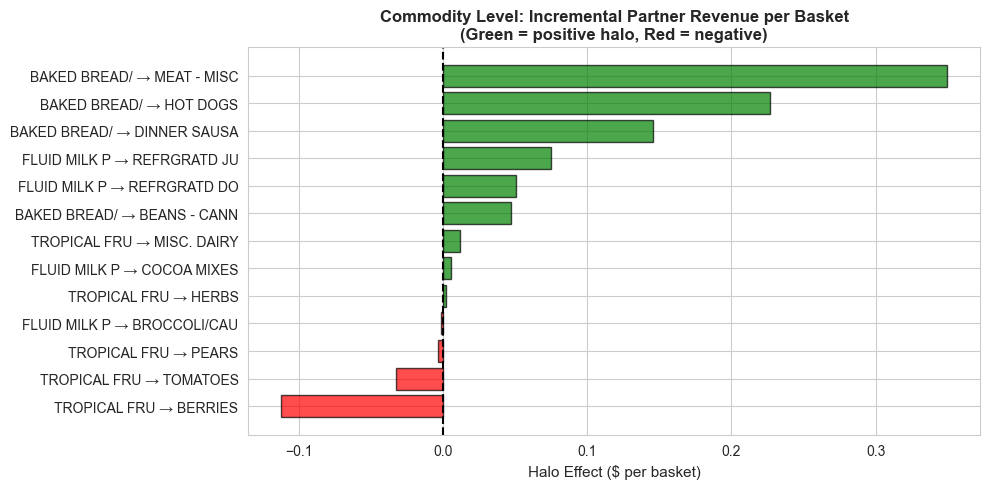

In [61]:
# Step 4.3.4: Visualise halo effect

fig, ax = plt.subplots(figsize=(10, 5))

commodity_plot = commodity_halo_df.sort_values('halo_effect_per_basket', ascending=True).tail(25)
colors = ['green' if x > 0 else 'red' for x in commodity_plot['halo_effect_per_basket']]
labels = commodity_plot['anchor_commodity'].str[:12] + ' → ' + commodity_plot['partner_commodity'].str[:12]

ax.barh(labels, commodity_plot['halo_effect_per_basket'], color=colors, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
ax.set_xlabel('Halo Effect ($ per basket)', fontsize=11)
ax.set_title('Commodity Level: Incremental Partner Revenue per Basket\n(Green = positive halo, Red = negative)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [62]:
# =============================================================================
# TASK 4.4: TEST IF DISPLAYING AFFINITY PRODUCTS TOGETHER 
#           INCREASES COMBINED PURCHASE PROBABILITY
# =============================================================================

# Step 4.4.1: Filter to relevant commodities only (anchors + partners)

relevant_commodities_display = set(
    commodity_anchor_partners['ANCHOR'].tolist() + 
    commodity_anchor_partners['PARTNER'].tolist()
)

print(f"Relevant commodities for display analysis: {len(relevant_commodities_display)}")
print(f"Anchor-partner pairs to analyse: {len(commodity_anchor_partners)}")

Relevant commodities for display analysis: 16
Anchor-partner pairs to analyse: 15


In [63]:
# Step 4.4.2: Filter causal_data to relevant commodities and get display locations

# Add commodity info to causal_data
causal_with_commodity = causal_data.merge(
    product_data[['PRODUCT_ID', 'COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='inner'
)

# Filter to relevant commodities only
causal_with_commodity = causal_with_commodity[
    causal_with_commodity['COMMODITY_DESC'].isin(relevant_commodities_display)
]

# Filter to products that ARE on display (DISPLAY > 0)
causal_displayed = causal_with_commodity[causal_with_commodity['DISPLAY'] != '0'].copy()

print(f"Causal records for relevant commodities: {len(causal_with_commodity):,}")
print(f"Records where product is on display: {len(causal_displayed):,}")

# Get display locations per commodity-store-week
# A commodity can be in multiple display locations, so we collect all of them
commodity_display_locations = causal_displayed.groupby(
    ['STORE_ID', 'WEEK_NO', 'COMMODITY_DESC']
)['DISPLAY'].apply(set).reset_index()

commodity_display_locations.columns = ['STORE_ID', 'WEEK_NO', 'COMMODITY_DESC', 'display_locations']

print(f"Commodity-store-week display records: {len(commodity_display_locations):,}")

Causal records for relevant commodities: 3,019,600
Records where product is on display: 1,187,841
Commodity-store-week display records: 64,107


In [64]:
# Step 4.4.3: Filter transactions to relevant commodities

transactions_display = transactions_with_promo[
    transactions_with_promo['COMMODITY_DESC'].isin(relevant_commodities_display)
].copy()

print(f"Transactions for relevant commodities: {len(transactions_display):,}")

# Create basket-level commodity presence with store-week info
basket_commodities_by_storeweek = transactions_display.groupby(
    ['BASKET_ID', 'STORE_ID', 'WEEK_NO']
)['COMMODITY_DESC'].apply(set).reset_index()

basket_commodities_by_storeweek.columns = ['BASKET_ID', 'STORE_ID', 'WEEK_NO', 'commodities']

print(f"Baskets with store-week info: {len(basket_commodities_by_storeweek):,}")

Transactions for relevant commodities: 320,331
Baskets with store-week info: 107,220


In [65]:
# Step 4.4.4: Calculate pair frequency (co-occurrence count) at commodity level

pair_frequency = {}

for _, row in commodity_anchor_partners.drop_duplicates(subset=['ANCHOR', 'PARTNER']).iterrows():
    anchor = row['ANCHOR']
    partner = row['PARTNER']
    
    count = basket_commodities_by_storeweek['commodities'].apply(
        lambda x: anchor in x and partner in x
    ).sum()
    
    pair_frequency[(anchor, partner)] = count

print(f"Pair frequencies calculated for {len(pair_frequency)} pairs")

Pair frequencies calculated for 13 pairs


In [66]:
# -----------------------------------------------------------------------------
# Step 4.4.5: Calculate co-purchase rates by display condition
#             - "co_displayed": both on display in SAME location
#             - "both_displayed_separate": both on display but DIFFERENT locations
#             - "neither": neither on display
# -----------------------------------------------------------------------------

display_impact_results = []

pairs_to_analyse = commodity_anchor_partners.drop_duplicates(subset=['ANCHOR', 'PARTNER'])
print(f"Analysing {len(pairs_to_analyse)} anchor-partner pairs...")

for idx, row in pairs_to_analyse.iterrows():
    anchor = row['ANCHOR']
    partner = row['PARTNER']
    baseline_lift = row['avg_lift']
    
    # Get display locations for anchor by store-week
    anchor_display = commodity_display_locations[
        commodity_display_locations['COMMODITY_DESC'] == anchor
    ][['STORE_ID', 'WEEK_NO', 'display_locations']].copy()
    anchor_display.columns = ['STORE_ID', 'WEEK_NO', 'anchor_locations']
    
    # Get display locations for partner by store-week
    partner_display = commodity_display_locations[
        commodity_display_locations['COMMODITY_DESC'] == partner
    ][['STORE_ID', 'WEEK_NO', 'display_locations']].copy()
    partner_display.columns = ['STORE_ID', 'WEEK_NO', 'partner_locations']
    
    # Get all store-weeks from baskets for this analysis
    all_store_weeks = basket_commodities_by_storeweek[['STORE_ID', 'WEEK_NO']].drop_duplicates()
    
    # Merge display info onto all store-weeks
    store_week_display = all_store_weeks.merge(anchor_display, on=['STORE_ID', 'WEEK_NO'], how='left')
    store_week_display = store_week_display.merge(partner_display, on=['STORE_ID', 'WEEK_NO'], how='left')
    
    # Classify store-weeks by display condition
    def classify_display(row):
        anchor_locs = row['anchor_locations'] if pd.notna(row['anchor_locations']) else set()
        partner_locs = row['partner_locations'] if pd.notna(row['partner_locations']) else set()
        
        # Handle case where locations are stored as non-set (e.g., after merge)
        if not isinstance(anchor_locs, set):
            anchor_locs = set()
        if not isinstance(partner_locs, set):
            partner_locs = set()
        
        anchor_displayed = len(anchor_locs) > 0
        partner_displayed = len(partner_locs) > 0
        
        if anchor_displayed and partner_displayed:
            # Check if they share any display location
            shared_locations = anchor_locs & partner_locs
            if len(shared_locations) > 0:
                return 'co_displayed'  # Same display location
            else:
                return 'both_displayed_separate'  # Different display locations
        elif not anchor_displayed and not partner_displayed:
            return 'neither'
        else:
            return 'one_only'
    
    store_week_display['display_condition'] = store_week_display.apply(classify_display, axis=1)
    
    # Merge with baskets
    baskets_with_display = basket_commodities_by_storeweek.merge(
        store_week_display[['STORE_ID', 'WEEK_NO', 'display_condition']],
        on=['STORE_ID', 'WEEK_NO'],
        how='inner'
    )
    
    if len(baskets_with_display) == 0:
        continue
    
    # Check if basket contains anchor and partner
    baskets_with_display['has_anchor'] = baskets_with_display['commodities'].apply(lambda x: anchor in x)
    baskets_with_display['has_partner'] = baskets_with_display['commodities'].apply(lambda x: partner in x)
    
    # Filter to baskets containing anchor
    anchor_baskets = baskets_with_display[baskets_with_display['has_anchor']]
    
    if len(anchor_baskets) == 0:
        continue
    
    # Calculate co-purchase rate by display condition
    copurchase_by_condition = anchor_baskets.groupby('display_condition')['has_partner'].agg(['mean', 'count'])
    copurchase_by_condition.columns = ['copurchase_rate', 'n_baskets']
    
    # Extract rates for each condition
    co_displayed_rate = copurchase_by_condition.loc['co_displayed', 'copurchase_rate'] if 'co_displayed' in copurchase_by_condition.index else np.nan
    separate_rate = copurchase_by_condition.loc['both_displayed_separate', 'copurchase_rate'] if 'both_displayed_separate' in copurchase_by_condition.index else np.nan
    neither_rate = copurchase_by_condition.loc['neither', 'copurchase_rate'] if 'neither' in copurchase_by_condition.index else np.nan
    
    co_displayed_count = copurchase_by_condition.loc['co_displayed', 'n_baskets'] if 'co_displayed' in copurchase_by_condition.index else 0
    separate_count = copurchase_by_condition.loc['both_displayed_separate', 'n_baskets'] if 'both_displayed_separate' in copurchase_by_condition.index else 0
    neither_count = copurchase_by_condition.loc['neither', 'n_baskets'] if 'neither' in copurchase_by_condition.index else 0
    
    # Calculate display lifts
    # Co-display lift: co-displayed vs neither
    if pd.notna(co_displayed_rate) and pd.notna(neither_rate) and neither_rate > 0:
        co_display_lift = co_displayed_rate / neither_rate
    else:
        co_display_lift = np.nan
    
    # Separate display lift: both displayed but separate vs neither
    if pd.notna(separate_rate) and pd.notna(neither_rate) and neither_rate > 0:
        separate_display_lift = separate_rate / neither_rate
    else:
        separate_display_lift = np.nan
    
    display_impact_results.append({
        'anchor_commodity': anchor,
        'partner_commodity': partner,
        'baseline_affinity_lift': baseline_lift,
        'pair_frequency': pair_frequency.get((anchor, partner), 0),
        'copurchase_rate_co_displayed': co_displayed_rate,
        'copurchase_rate_separate': separate_rate,
        'copurchase_rate_neither': neither_rate,
        'n_baskets_co_displayed': co_displayed_count,
        'n_baskets_separate': separate_count,
        'n_baskets_neither': neither_count,
        'co_display_lift': co_display_lift,
        'separate_display_lift': separate_display_lift
    })

display_impact_df = pd.DataFrame(display_impact_results)

print("\n" + "=" * 100)
print("DISPLAY IMPACT: CO-PURCHASE RATES BY DISPLAY CONDITION")
print("=" * 100)
print("\nCo-display lift: same display location vs neither displayed")
print("Separate display lift: different display locations vs neither displayed\n")
display(display_impact_df.sort_values('co_display_lift', ascending=False))

Analysing 13 anchor-partner pairs...

DISPLAY IMPACT: CO-PURCHASE RATES BY DISPLAY CONDITION

Co-display lift: same display location vs neither displayed
Separate display lift: different display locations vs neither displayed



,anchor_commodity,partner_commodity,baseline_affinity_lift,pair_frequency,copurchase_rate_co_displayed,copurchase_rate_separate,copurchase_rate_neither,n_baskets_co_displayed,n_baskets_separate,n_baskets_neither,co_display_lift,separate_display_lift
3,TROPICAL FRUIT,PEARS,3.156924,1129,0.135135,0.050000,0.037788,37,20,28422,3.576174,1.323184
8,FLUID MILK PRODUCTS,BROCCOLI/CAULIFLOWER,2.940209,2483,0.076923,0.087549,0.039762,143,514,38529,1.934575,2.201803
1,TROPICAL FRUIT,TOMATOES,3.595889,5608,0.255486,0.189655,0.188057,638,58,27699,1.358553,1.008497
2,TROPICAL FRUIT,BERRIES,3.233782,4315,0.191748,0.151515,0.144010,412,99,28262,1.331491,1.052118
0,TROPICAL FRUIT,HERBS,5.035523,1213,0.052137,0.096774,0.040206,1170,93,25618,1.296737,2.406953
10,BAKED BREAD/BUNS/ROLLS,MEAT - MISC,7.831185,4934,0.094143,0.093554,0.075491,27405,11822,4782,1.247074,1.239272
4,TROPICAL FRUIT,MISC. DAIRY,3.149298,2572,0.102740,0.079602,0.085309,146,402,19107,1.204324,0.933101
6,FLUID MILK PRODUCTS,COCOA MIXES,3.127181,2316,0.042733,0.042217,0.035570,3791,6585,25949,1.201379,1.186883
7,FLUID MILK PRODUCTS,REFRGRATD DOUGH PRODUCTS,2.951517,7934,0.141671,0.144206,0.119325,5301,10908,13920,1.187276,1.208518
11,BAKED BREAD/BUNS/ROLLS,HOT DOGS,6.816925,7454,0.150569,0.140928,0.134131,18005,15547,6352,1.122554,1.050671


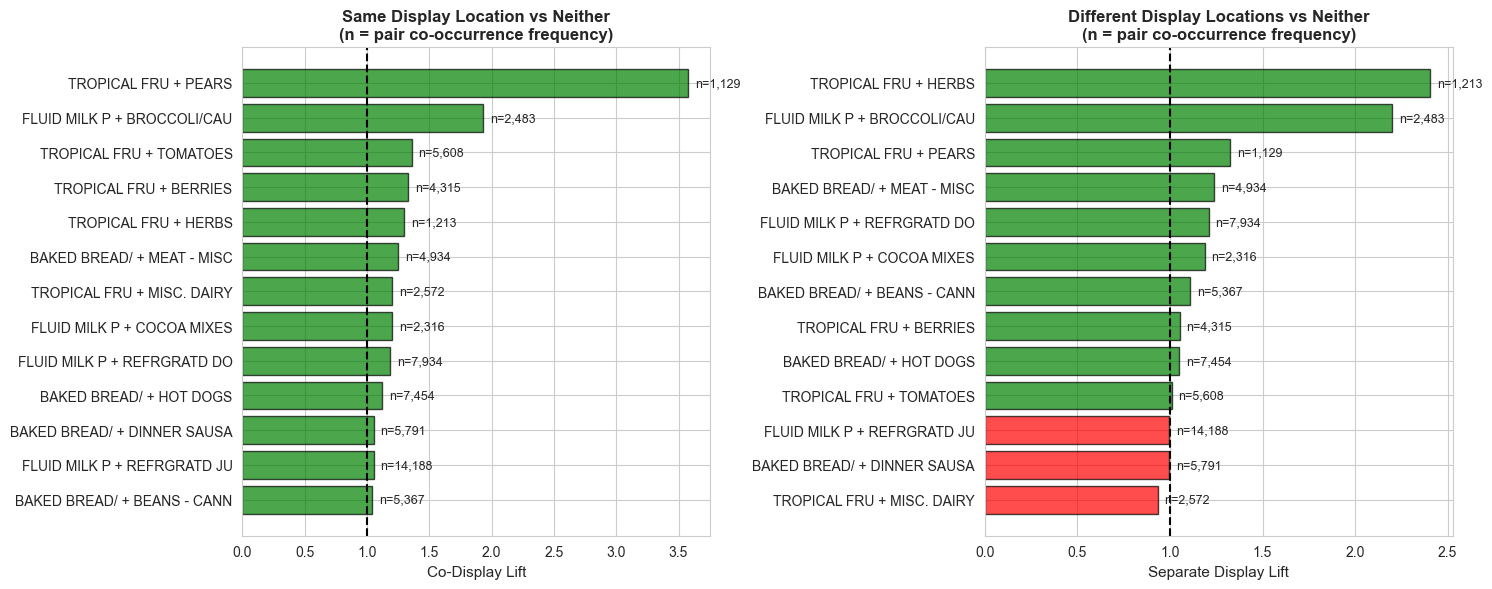

In [67]:
# Step 4.4.6: Visualise display impact with pair frequency annotations

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Co-display lift (same location)
ax1 = axes[0]
plot_df_co = display_impact_df[
    display_impact_df['co_display_lift'].notna()
].sort_values('co_display_lift', ascending=True)

if len(plot_df_co) > 0:
    colors = ['green' if x > 1 else 'red' for x in plot_df_co['co_display_lift']]
    labels = plot_df_co['anchor_commodity'].str[:12] + ' + ' + plot_df_co['partner_commodity'].str[:12]
    
    ax1.barh(labels, plot_df_co['co_display_lift'], color=colors, edgecolor='black', alpha=0.7)
    ax1.axvline(x=1, color='black', linestyle='--', linewidth=1.5)
    
    for i, (_, row) in enumerate(plot_df_co.iterrows()):
        ax1.annotate(f"n={row['pair_frequency']:,}", 
                    xy=(row['co_display_lift'], i),
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=9,
                    va='center')
    
    ax1.set_xlabel('Co-Display Lift', fontsize=11)
    ax1.set_title('Same Display Location vs Neither\n(n = pair co-occurrence frequency)', fontsize=12, fontweight='bold')

# Plot 2: Separate display lift (different locations)
ax2 = axes[1]
plot_df_sep = display_impact_df[
    display_impact_df['separate_display_lift'].notna()
].sort_values('separate_display_lift', ascending=True)

if len(plot_df_sep) > 0:
    colors = ['green' if x > 1 else 'red' for x in plot_df_sep['separate_display_lift']]
    labels = plot_df_sep['anchor_commodity'].str[:12] + ' + ' + plot_df_sep['partner_commodity'].str[:12]
    
    ax2.barh(labels, plot_df_sep['separate_display_lift'], color=colors, edgecolor='black', alpha=0.7)
    ax2.axvline(x=1, color='black', linestyle='--', linewidth=1.5)
    
    for i, (_, row) in enumerate(plot_df_sep.iterrows()):
        ax2.annotate(f"n={row['pair_frequency']:,}", 
                    xy=(row['separate_display_lift'], i),
                    xytext=(5, 0),
                    textcoords='offset points',
                    fontsize=9,
                    va='center')
    
    ax2.set_xlabel('Separate Display Lift', fontsize=11)
    ax2.set_title('Different Display Locations vs Neither\n(n = pair co-occurrence frequency)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [68]:
# Step 4.4.7: Summary

print("\n" + "=" * 100)
print("DISPLAY IMPACT SUMMARY")
print("=" * 100)

valid_co = display_impact_df[display_impact_df['co_display_lift'].notna()]
valid_sep = display_impact_df[display_impact_df['separate_display_lift'].notna()]

print(f"\nCO-DISPLAY (Same Location):")
print(f"  • Pairs with data: {len(valid_co)}")
print(f"  • Pairs with lift > 1: {(valid_co['co_display_lift'] > 1).sum()}")
print(f"  • Average lift: {valid_co['co_display_lift'].mean():.2f}")

print(f"\nSEPARATE DISPLAY (Different Locations):")
print(f"  • Pairs with data: {len(valid_sep)}")
print(f"  • Pairs with lift > 1: {(valid_sep['separate_display_lift'] > 1).sum()}")
print(f"  • Average lift: {valid_sep['separate_display_lift'].mean():.2f}")

print("\n" + "-" * 100)
print("TOP 5 PAIRS BENEFITING FROM CO-DISPLAY (Same Location):")
for _, row in valid_co.nlargest(5, 'co_display_lift').iterrows():
    print(f"  • {row['anchor_commodity']} + {row['partner_commodity']}: "
          f"lift = {row['co_display_lift']:.2f}, frequency = {row['pair_frequency']:,} "
          f"({row['copurchase_rate_co_displayed']:.1%} vs {row['copurchase_rate_neither']:.1%})")




DISPLAY IMPACT SUMMARY

CO-DISPLAY (Same Location):
  • Pairs with data: 13
  • Pairs with lift > 1: 13
  • Average lift: 1.43

SEPARATE DISPLAY (Different Locations):
  • Pairs with data: 13
  • Pairs with lift > 1: 10
  • Average lift: 1.29

----------------------------------------------------------------------------------------------------
TOP 5 PAIRS BENEFITING FROM CO-DISPLAY (Same Location):
  • TROPICAL FRUIT + PEARS: lift = 3.58, frequency = 1,129 (13.5% vs 3.8%)
  • FLUID MILK PRODUCTS + BROCCOLI/CAULIFLOWER: lift = 1.93, frequency = 2,483 (7.7% vs 4.0%)
  • TROPICAL FRUIT + TOMATOES: lift = 1.36, frequency = 5,608 (25.5% vs 18.8%)
  • TROPICAL FRUIT + BERRIES: lift = 1.33, frequency = 4,315 (19.2% vs 14.4%)
  • TROPICAL FRUIT + HERBS: lift = 1.30, frequency = 1,213 (5.2% vs 4.0%)


In [69]:
# =============================================================================
# TASK 5: CUSTOMER SEGMENTATION BY PURCHASE PATTERNS
# Step 5.1: Build household-level feature matrix
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Step 5.1.1: Start with transaction data joined to product metadata

# Join transaction_data with product_data to get department info
transactions_full = transaction_data.merge(
    product_data[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='left'
)

print(f"Transactions with product metadata: {len(transactions_full):,}")
print(f"Unique households: {transactions_full['household_key'].nunique():,}")
print(f"Unique baskets: {transactions_full['BASKET_ID'].nunique():,}")

Transactions with product metadata: 2,595,732
Unique households: 2,500
Unique baskets: 276,484


In [70]:
# Step 5.1.2: Calculate basket-level metrics per household

# Basket summary: size, value, departments per basket
basket_summary = transactions_full.groupby(['household_key', 'BASKET_ID']).agg({
    'PRODUCT_ID': 'count',           # basket size (number of items)
    'SALES_VALUE': 'sum',            # basket value
    'DEPARTMENT': 'nunique',         # department diversity per basket
    'DAY': 'first'                   # keep day for frequency calculation
}).reset_index()

basket_summary.columns = ['household_key', 'BASKET_ID', 'basket_size', 'basket_value', 'dept_diversity', 'day']

# filter for meaningful baskets (3+ items and spend of 5+)
basket_summary = basket_summary[
    (basket_summary['basket_size'] >= 3) & 
    (basket_summary['basket_value'] >= 5)
]

print("Basket summary sample:")
display(basket_summary.head(10))

Basket summary sample:


,household_key,BASKET_ID,basket_size,basket_value,dept_diversity,day
0,1,27601281299,30,78.66,6,51
1,1,27774192959,12,41.10,3,67
2,1,28024266849,12,26.90,4,88
3,1,28106322445,23,63.43,4,94
4,1,28235481967,17,53.45,5,101
5,1,28282581446,10,26.76,5,108
6,1,28318295376,9,23.55,4,111
7,1,28601601153,39,110.34,6,128
8,1,28744672720,36,87.44,7,137
9,1,28853646373,29,73.32,6,146


In [71]:
# Step 5.1.3: Calculate household-level aggregates

household_metrics = basket_summary.groupby('household_key').agg({
    'BASKET_ID': 'count',            # number of shopping trips
    'basket_size': 'mean',           # average basket size
    'basket_value': ['mean', 'sum'], # average and total spend
    'dept_diversity': 'mean',        # average departments per trip
    'day': lambda x: x.max() - x.min()  # shopping span (days between first and last)
}).reset_index()

# Flatten column names
household_metrics.columns = [
    'household_key', 'num_trips', 'avg_basket_size', 
    'avg_basket_value', 'total_spend', 'avg_dept_diversity', 'shopping_span'
]

# Calculate trip frequency (trips per week, assuming ~102 weeks of data)
household_metrics['trips_per_week'] = household_metrics['num_trips'] / (household_metrics['shopping_span'] / 7 + 1)

print(f"Households profiled: {len(household_metrics):,}")
display(household_metrics.head(10))

Households profiled: 2,499


,household_key,num_trips,avg_basket_size,avg_basket_value,total_spend,avg_dept_diversity,shopping_span,trips_per_week
0,1,69,24.739130,61.661449,4254.64,4.739130,655,0.729607
1,2,41,17.292683,46.940488,1924.56,3.560976,565,0.501748
2,3,40,22.700000,65.143250,2605.73,3.500000,590,0.469012
3,4,27,11.000000,43.864815,1184.35,2.740741,523,0.356604
4,5,24,8.208333,25.939167,622.54,2.666667,501,0.330709
5,6,196,8.698980,27.442653,5378.76,3.163265,589,2.302013
6,7,56,22.875000,60.300893,3376.85,4.053571,686,0.565657
7,8,99,19.787879,52.803939,5227.59,3.898990,641,1.069444
8,9,17,12.705882,44.858235,762.59,2.647059,585,0.201014
9,10,7,9.428571,31.387143,219.71,3.000000,571,0.084775


In [72]:
# Step 5.1.4: Calculate department penetration per household
# (What % of their baskets contain each department?)

# Count baskets per household containing each department
household_dept = transactions_full.groupby(['household_key', 'DEPARTMENT'])['BASKET_ID'].nunique().reset_index()
household_dept.columns = ['household_key', 'DEPARTMENT', 'baskets_with_dept']

# Get total baskets per household
household_total_baskets = transactions_full.groupby('household_key')['BASKET_ID'].nunique().reset_index()
household_total_baskets.columns = ['household_key', 'total_baskets']

# Merge and calculate penetration
household_dept = household_dept.merge(household_total_baskets, on='household_key')
household_dept['penetration'] = household_dept['baskets_with_dept'] / household_dept['total_baskets']

# Pivot to create household × department matrix
dept_penetration = household_dept.pivot(
    index='household_key',
    columns='DEPARTMENT',
    values='penetration'
).fillna(0).reset_index()

print(f"Department penetration matrix shape: {dept_penetration.shape}")
display(dept_penetration.head(10))

Department penetration matrix shape: (2500, 45)


DEPARTMENT,household_key,,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,ELECT &PLUMBING,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,KIOSK-GAS,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL
0,1,0.151163,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.488372,0.0,0.697674,0.0,0.011628,0.0,0.000000,0.0,0.0,0.848837,0.0,0.0,0.000000,0.046512,0.581395,0.0,0.023256,0.000000,0.174419,0.279070,0.0,0.0,0.0,0.0,0.0,0.593023,0.034884,0.0,0.104651,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,2,0.000000,0.0,0.0,0.000000,0.0,0.066667,0.0,0.00000,0.200000,0.0,0.622222,0.0,0.022222,0.0,0.000000,0.0,0.0,0.888889,0.0,0.0,0.000000,0.377778,0.266667,0.0,0.022222,0.000000,0.066667,0.244444,0.0,0.0,0.0,0.0,0.0,0.533333,0.000000,0.0,0.000000,0.000000,0.022222,0.000000,0.0,0.0,0.0,0.0
2,3,0.021277,0.0,0.0,0.000000,0.0,0.021277,0.0,0.00000,0.063830,0.0,0.595745,0.0,0.000000,0.0,0.000000,0.0,0.0,0.936170,0.0,0.0,0.021277,0.489362,0.531915,0.0,0.000000,0.000000,0.000000,0.021277,0.0,0.0,0.0,0.0,0.0,0.425532,0.000000,0.0,0.021277,0.000000,0.042553,0.000000,0.0,0.0,0.0,0.0
3,4,0.000000,0.0,0.0,0.000000,0.0,0.066667,0.0,0.00000,0.066667,0.0,0.566667,0.0,0.000000,0.0,0.000000,0.0,0.0,0.966667,0.0,0.0,0.000000,0.200000,0.533333,0.0,0.000000,0.000000,0.033333,0.000000,0.0,0.0,0.0,0.0,0.0,0.066667,0.000000,0.0,0.000000,0.000000,0.100000,0.000000,0.0,0.0,0.0,0.0
4,5,0.000000,0.0,0.0,0.000000,0.0,0.050000,0.0,0.00000,0.350000,0.0,0.475000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.725000,0.0,0.0,0.000000,0.175000,0.250000,0.0,0.000000,0.000000,0.050000,0.025000,0.0,0.0,0.0,0.0,0.0,0.025000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
5,6,0.008000,0.0,0.0,0.004000,0.0,0.008000,0.0,0.00000,0.076000,0.0,0.424000,0.0,0.008000,0.0,0.008000,0.0,0.0,0.748000,0.0,0.0,0.032000,0.432000,0.028000,0.0,0.008000,0.000000,0.048000,0.136000,0.0,0.0,0.0,0.0,0.0,0.668000,0.000000,0.0,0.028000,0.060000,0.020000,0.000000,0.0,0.0,0.0,0.0
6,7,0.084746,0.0,0.0,0.000000,0.0,0.135593,0.0,0.00000,0.305085,0.0,0.813559,0.0,0.016949,0.0,0.000000,0.0,0.0,0.949153,0.0,0.0,0.000000,0.322034,0.305085,0.0,0.000000,0.016949,0.118644,0.152542,0.0,0.0,0.0,0.0,0.0,0.661017,0.000000,0.0,0.000000,0.016949,0.000000,0.000000,0.0,0.0,0.0,0.0
7,8,0.061947,0.0,0.0,0.017699,0.0,0.026549,0.0,0.00885,0.159292,0.0,0.619469,0.0,0.053097,0.0,0.017699,0.0,0.0,0.902655,0.0,0.0,0.070796,0.345133,0.389381,0.0,0.008850,0.000000,0.008850,0.115044,0.0,0.0,0.0,0.0,0.0,0.486726,0.000000,0.0,0.194690,0.008850,0.053097,0.035398,0.0,0.0,0.0,0.0
8,9,0.000000,0.0,0.0,0.050000,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.600000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.950000,0.0,0.0,0.000000,0.100000,0.350000,0.0,0.000000,0.000000,0.050000,0.050000,0.0,0.0,0.0,0.0,0.0,0.250000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
9,10,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.222222,0.0,0.444444,0.0,0.000000,0.0,0.000000,0.0,0.0,0.888889,0.0,0.0,0.000000,0.222222,0.333333,0.0,0.000000,0.000000,0.111111,0.000000,0.0,0.0,0.0,0.0,0.0,0.333333,0.000000,0.0,0.111111,0.000000,0.111111,0.000000,0.0,0.0,0.0,0.0


In [73]:
# Step 5.1.5: Combine all features into single household feature matrix

household_features = household_metrics.merge(dept_penetration, on='household_key')

print(f"Final feature matrix shape: {household_features.shape}")
print(f"\nFeatures:")
print(household_features.columns.tolist())

display(household_features.head(10))

Final feature matrix shape: (2499, 52)

Features:
['household_key', 'num_trips', 'avg_basket_size', 'avg_basket_value', 'total_spend', 'avg_dept_diversity', 'shopping_span', 'trips_per_week', ' ', 'AUTOMOTIVE', 'CHARITABLE CONT', 'CHEF SHOPPE', 'CNTRL/STORE SUP', 'COSMETICS', 'COUP/STR & MFG', 'DAIRY DELI', 'DELI', 'DELI/SNACK BAR', 'DRUG GM', 'ELECT &PLUMBING', 'FLORAL', 'FROZEN GROCERY', 'GARDEN CENTER', 'GM MERCH EXP', 'GRO BAKERY', 'GROCERY', 'HBC', 'HOUSEWARES', 'KIOSK-GAS', 'MEAT', 'MEAT-PCKGD', 'MEAT-WHSE', 'MISC SALES TRAN', 'MISC. TRANS.', 'NUTRITION', 'PASTRY', 'PHARMACY SUPPLY', 'PHOTO', 'PORK', 'POSTAL CENTER', 'PROD-WHS SALES', 'PRODUCE', 'RESTAURANT', 'RX', 'SALAD BAR', 'SEAFOOD', 'SEAFOOD-PCKGD', 'SPIRITS', 'TOYS', 'TRAVEL & LEISUR', 'VIDEO', 'VIDEO RENTAL']


,household_key,num_trips,avg_basket_size,avg_basket_value,total_spend,avg_dept_diversity,shopping_span,trips_per_week,,AUTOMOTIVE,CHARITABLE CONT,CHEF SHOPPE,CNTRL/STORE SUP,COSMETICS,COUP/STR & MFG,DAIRY DELI,DELI,DELI/SNACK BAR,DRUG GM,ELECT &PLUMBING,FLORAL,FROZEN GROCERY,GARDEN CENTER,GM MERCH EXP,GRO BAKERY,GROCERY,HBC,HOUSEWARES,KIOSK-GAS,MEAT,MEAT-PCKGD,MEAT-WHSE,MISC SALES TRAN,MISC. TRANS.,NUTRITION,PASTRY,PHARMACY SUPPLY,PHOTO,PORK,POSTAL CENTER,PROD-WHS SALES,PRODUCE,RESTAURANT,RX,SALAD BAR,SEAFOOD,SEAFOOD-PCKGD,SPIRITS,TOYS,TRAVEL & LEISUR,VIDEO,VIDEO RENTAL
0,1,69,24.739130,61.661449,4254.64,4.739130,655,0.729607,0.151163,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.488372,0.0,0.697674,0.0,0.011628,0.0,0.000000,0.0,0.0,0.848837,0.0,0.0,0.000000,0.046512,0.581395,0.0,0.023256,0.000000,0.174419,0.279070,0.0,0.0,0.0,0.0,0.0,0.593023,0.034884,0.0,0.104651,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
1,2,41,17.292683,46.940488,1924.56,3.560976,565,0.501748,0.000000,0.0,0.0,0.000000,0.0,0.066667,0.0,0.00000,0.200000,0.0,0.622222,0.0,0.022222,0.0,0.000000,0.0,0.0,0.888889,0.0,0.0,0.000000,0.377778,0.266667,0.0,0.022222,0.000000,0.066667,0.244444,0.0,0.0,0.0,0.0,0.0,0.533333,0.000000,0.0,0.000000,0.000000,0.022222,0.000000,0.0,0.0,0.0,0.0
2,3,40,22.700000,65.143250,2605.73,3.500000,590,0.469012,0.021277,0.0,0.0,0.000000,0.0,0.021277,0.0,0.00000,0.063830,0.0,0.595745,0.0,0.000000,0.0,0.000000,0.0,0.0,0.936170,0.0,0.0,0.021277,0.489362,0.531915,0.0,0.000000,0.000000,0.000000,0.021277,0.0,0.0,0.0,0.0,0.0,0.425532,0.000000,0.0,0.021277,0.000000,0.042553,0.000000,0.0,0.0,0.0,0.0
3,4,27,11.000000,43.864815,1184.35,2.740741,523,0.356604,0.000000,0.0,0.0,0.000000,0.0,0.066667,0.0,0.00000,0.066667,0.0,0.566667,0.0,0.000000,0.0,0.000000,0.0,0.0,0.966667,0.0,0.0,0.000000,0.200000,0.533333,0.0,0.000000,0.000000,0.033333,0.000000,0.0,0.0,0.0,0.0,0.0,0.066667,0.000000,0.0,0.000000,0.000000,0.100000,0.000000,0.0,0.0,0.0,0.0
4,5,24,8.208333,25.939167,622.54,2.666667,501,0.330709,0.000000,0.0,0.0,0.000000,0.0,0.050000,0.0,0.00000,0.350000,0.0,0.475000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.725000,0.0,0.0,0.000000,0.175000,0.250000,0.0,0.000000,0.000000,0.050000,0.025000,0.0,0.0,0.0,0.0,0.0,0.025000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
5,6,196,8.698980,27.442653,5378.76,3.163265,589,2.302013,0.008000,0.0,0.0,0.004000,0.0,0.008000,0.0,0.00000,0.076000,0.0,0.424000,0.0,0.008000,0.0,0.008000,0.0,0.0,0.748000,0.0,0.0,0.032000,0.432000,0.028000,0.0,0.008000,0.000000,0.048000,0.136000,0.0,0.0,0.0,0.0,0.0,0.668000,0.000000,0.0,0.028000,0.060000,0.020000,0.000000,0.0,0.0,0.0,0.0
6,7,56,22.875000,60.300893,3376.85,4.053571,686,0.565657,0.084746,0.0,0.0,0.000000,0.0,0.135593,0.0,0.00000,0.305085,0.0,0.813559,0.0,0.016949,0.0,0.000000,0.0,0.0,0.949153,0.0,0.0,0.000000,0.322034,0.305085,0.0,0.000000,0.016949,0.118644,0.152542,0.0,0.0,0.0,0.0,0.0,0.661017,0.000000,0.0,0.000000,0.016949,0.000000,0.000000,0.0,0.0,0.0,0.0
7,8,99,19.787879,52.803939,5227.59,3.898990,641,1.069444,0.061947,0.0,0.0,0.017699,0.0,0.026549,0.0,0.00885,0.159292,0.0,0.619469,0.0,0.053097,0.0,0.017699,0.0,0.0,0.902655,0.0,0.0,0.070796,0.345133,0.389381,0.0,0.008850,0.000000,0.008850,0.115044,0.0,0.0,0.0,0.0,0.0,0.486726,0.000000,0.0,0.194690,0.008850,0.053097,0.035398,0.0,0.0,0.0,0.0
8,9,17,12.705882,44.858235,762.59,2.647059,585,0.201014,0.000000,0.0,0.0,0.050000,0.0,0.000000,0.0,0.00000,0.000000,0.0,0.600000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.950000,0.0,0.0,0.000000,0.100000,0.350000,0.0,0.000000,0.000000,0.050000,0.050000,0.0,0.0,0.0,0.0,0.0,0.250000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0
9,10,7,9.428571,31.387143,219.71,3.000000,571,0.084775,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.00000,0.222222,0.0,0.444444,0.0,0.000000,0.0,0.000000,0.0,0.0,0.888889,0.0,0.0,0.000000,0.222222,0.333333,0.0,0.000000,0.000000,0.111111,0.000000,0.0,0.0,0.0,0.0,0.0,0.333333,0.000000,0.0,0.111111,0.000000,0.111111,0.000000,0.0,0.0,0.0,0.0


In [74]:
# Step 5.1.6: Prepare features for clustering

# Separate household_key (identifier) from features
feature_columns = [col for col in household_features.columns if col != 'household_key']
X = household_features[feature_columns].copy()

# Handle any infinities or NaNs
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

# Scale features (important for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Scaled feature matrix shape: {X_scaled.shape}")
print(f"Features used for clustering: {len(feature_columns)}")

Scaled feature matrix shape: (2499, 51)
Features used for clustering: 51


In [75]:
# Step 5.2 (Simplified): Cluster using core behavioural features only

# Step 5.2.1: Select core features

core_features = ['avg_basket_size', 'avg_basket_value', 'total_spend', 'avg_dept_diversity', 'trips_per_week']

X_core = household_features[core_features].copy()

# Handle any infinities or NaNs
X_core = X_core.replace([np.inf, -np.inf], np.nan).fillna(0)

# Scale features
scaler_core = StandardScaler()
X_core_scaled = scaler_core.fit_transform(X_core)

print(f"Feature matrix shape: {X_core_scaled.shape}")
print(f"Features used: {core_features}")

Feature matrix shape: (2499, 5)
Features used: ['avg_basket_size', 'avg_basket_value', 'total_spend', 'avg_dept_diversity', 'trips_per_week']


k=2: WCSS=7,796
k=3: WCSS=5,844
k=4: WCSS=4,631
k=5: WCSS=4,006
k=6: WCSS=3,533
k=7: WCSS=3,189
k=8: WCSS=2,939
k=9: WCSS=2,713
k=10: WCSS=2,525


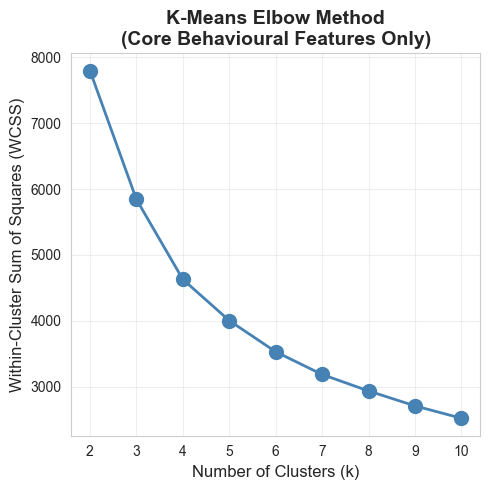


✓ Saved: kmeans_elbow_core_features.png


In [76]:
# Step 5.2.2: Elbow method with WCSS

k_range = range(2, 11)
wcss = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_core_scaled)
    wcss.append(kmeans.inertia_)
    print(f"k={k}: WCSS={kmeans.inertia_:,.0f}")

# Plot
plt.figure(figsize=(5, 5))
plt.plot(k_range, wcss, marker='o', linewidth=2, markersize=10, color='steelblue')
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
plt.title('K-Means Elbow Method\n(Core Behavioural Features Only)', fontsize=14, fontweight='bold')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('kmeans_elbow_core_features.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: kmeans_elbow_core_features.png")

In [77]:
# Step 5.3: Fit K-Means with k=4 and profile clusters

# Step 5.3.1: Fit final model

optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
household_features['cluster'] = kmeans_final.fit_predict(X_core_scaled)

print(f"Clustering complete with k={optimal_k}")
print(f"\nCluster distribution:")
print(household_features['cluster'].value_counts().sort_index())

Clustering complete with k=4

Cluster distribution:
0     318
1    1088
2     872
3     221
Name: cluster, dtype: int64


In [78]:
# Step 5.3.2: Profile clusters - Core behavioural metrics

cluster_profiles = household_features.groupby('cluster')[core_features].mean()

print("\n" + "=" * 80)
print("CLUSTER PROFILES (Core Features)")
print("=" * 80)
display(cluster_profiles)


CLUSTER PROFILES (Core Features)


,avg_basket_size,avg_basket_value,total_spend,avg_dept_diversity,trips_per_week
cluster,,,,,
0,13.621246,40.173713,7491.694748,3.281616,2.097433
1,8.856579,24.659295,1148.156213,2.584831,0.535449
2,16.213172,46.082208,2448.731078,3.512891,0.624938
3,28.774351,87.304950,5553.636425,4.543980,0.730561


In [79]:
# Step 5.4.1: Link baskets to household clusters

# Get cluster assignments per household
household_clusters = household_features[['household_key', 'cluster']].copy()

# Join to transaction data to tag each transaction with its household's cluster
transactions_clustered = transaction_data.merge(
    household_clusters,
    on='household_key',
    how='inner'
)

# Add product metadata
transactions_clustered = transactions_clustered.merge(
    product_data[['PRODUCT_ID', 'DEPARTMENT', 'COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='left'
)

# Remove transactions with blank or missing department/commodity
initial_count = len(transactions_clustered)
transactions_clustered = transactions_clustered[
    (transactions_clustered['DEPARTMENT'].notna()) & 
    (transactions_clustered['DEPARTMENT'] != ' ') &
    (transactions_clustered['DEPARTMENT'].str.strip() != '') &
    (transactions_clustered['COMMODITY_DESC'].notna()) & 
    (transactions_clustered['COMMODITY_DESC'] != ' ') &
    (transactions_clustered['COMMODITY_DESC'].str.strip() != '')
]
final_count = len(transactions_clustered)

print(f"Transactions with cluster assignment: {initial_count:,}")
print(f"After removing blank departments/commodities: {final_count:,}")
print(f"Removed: {initial_count - final_count:,} ({(initial_count - final_count) / initial_count * 100:.1f}%)")

print(f"\nTransactions per cluster:")
print(transactions_clustered.groupby('cluster')['BASKET_ID'].count())

Transactions with cluster assignment: 2,595,665
After removing blank departments/commodities: 2,587,827
Removed: 7,838 (0.3%)

Transactions per cluster:
cluster
0    865788
1    522271
2    790660
3    409108
Name: BASKET_ID, dtype: int64


In [80]:
# Step 5.4.2: Function to calculate affinity metrics for a subset of baskets

def calculate_affinity_for_cluster(transactions_df, level='DEPARTMENT', min_pair_count=50):
    """
    Calculate product pair affinity metrics for a given set of transactions.
    
    Parameters:
    - transactions_df: DataFrame with BASKET_ID and level column (DEPARTMENT or COMMODITY_DESC)
    - level: 'DEPARTMENT' or 'COMMODITY_DESC'
    - min_pair_count: minimum co-occurrences to include pair
    
    Returns:
    - DataFrame with affinity metrics per pair
    """
    
    # Get unique categories per basket
    basket_categories = transactions_df.groupby('BASKET_ID')[level].apply(set).reset_index()
    basket_categories.columns = ['BASKET_ID', 'categories']
    
    # Filter to baskets with 2+ categories (needed for pairs)
    basket_categories = basket_categories[basket_categories['categories'].apply(len) >= 2]
    
    total_baskets = len(basket_categories)
    
    if total_baskets == 0:
        return pd.DataFrame()
    
    # Count category occurrences
    category_counts = {}
    for cats in basket_categories['categories']:
        for cat in cats:
            category_counts[cat] = category_counts.get(cat, 0) + 1
    
    # Count pair co-occurrences
    from itertools import combinations
    pair_counts = {}
    for cats in basket_categories['categories']:
        for pair in combinations(sorted(cats), 2):
            pair_counts[pair] = pair_counts.get(pair, 0) + 1
    
    # Build results DataFrame
    results = []
    for (cat_a, cat_b), count in pair_counts.items():
        if count >= min_pair_count:
            support = count / total_baskets
            
            # Lift calculation
            p_a = category_counts.get(cat_a, 0) / total_baskets
            p_b = category_counts.get(cat_b, 0) / total_baskets
            
            if p_a > 0 and p_b > 0:
                lift = support / (p_a * p_b)
            else:
                lift = 0
            
            results.append({
                'category_A': cat_a,
                'category_B': cat_b,
                'pair_count': count,
                'support': support,
                'lift': lift
            })
    
    return pd.DataFrame(results)

In [81]:

# PART A: DEPARTMENT-LEVEL AFFINITY BY CLUSTER

print("=" * 100)
print("DEPARTMENT-LEVEL AFFINITY PATTERNS BY CLUSTER")
print("=" * 100)

dept_affinity_by_cluster = {}

for cluster_id in sorted(transactions_clustered['cluster'].unique()):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*50}")
    
    # Filter transactions to this cluster
    cluster_transactions = transactions_clustered[transactions_clustered['cluster'] == cluster_id]
    
    print(f"Baskets in cluster: {cluster_transactions['BASKET_ID'].nunique():,}")
    
    # Calculate affinity
    cluster_affinity = calculate_affinity_for_cluster(
        cluster_transactions, 
        level='DEPARTMENT', 
        min_pair_count=50
    )
    
    if len(cluster_affinity) > 0:
        cluster_affinity = cluster_affinity.sort_values('lift', ascending=False)
        dept_affinity_by_cluster[cluster_id] = cluster_affinity
        
        print(f"Affinity pairs found: {len(cluster_affinity)}")
        print(f"\nTop 10 Department Pairs by Lift:")
        display(cluster_affinity.head(10))
    else:
        print("No significant affinity pairs found.")

DEPARTMENT-LEVEL AFFINITY PATTERNS BY CLUSTER

CLUSTER 0
Baskets in cluster: 98,375
Affinity pairs found: 130

Top 10 Department Pairs by Lift:


,category_A,category_B,pair_count,support,lift
55,SEAFOOD,SEAFOOD-PCKGD,296,0.004772,4.830346
109,COSMETICS,MISC SALES TRAN,61,0.000983,2.103790
108,CHEF SHOPPE,MEAT,161,0.002595,1.996808
122,COSMETICS,FLORAL,64,0.001032,1.903733
87,FROZEN GROCERY,PRODUCE,58,0.000935,1.883519
120,MISC. TRANS.,SALAD BAR,73,0.001177,1.865630
67,NUTRITION,SEAFOOD,211,0.003401,1.858934
75,CHEF SHOPPE,PASTRY,84,0.001354,1.834030
71,CHEF SHOPPE,DELI,97,0.001564,1.789343
76,CHEF SHOPPE,PRODUCE,238,0.003837,1.766611



CLUSTER 1
Baskets in cluster: 90,546
Affinity pairs found: 91

Top 10 Department Pairs by Lift:


,category_A,category_B,pair_count,support,lift
87,SEAFOOD,SEAFOOD-PCKGD,98,0.001928,6.092444
90,CHEF SHOPPE,PRODUCE,75,0.001476,2.115104
86,PRODUCE,TRAVEL & LEISUR,116,0.002283,1.929264
62,DRUG GM,KIOSK-GAS,173,0.003404,1.631753
11,MEAT,SEAFOOD-PCKGD,573,0.011275,1.597859
12,MEAT-PCKGD,SEAFOOD-PCKGD,645,0.012692,1.590255
44,COSMETICS,DRUG GM,701,0.013794,1.551477
65,MEAT,SEAFOOD,182,0.003581,1.528412
16,PRODUCE,SEAFOOD,297,0.005844,1.479030
72,MEAT,MISC SALES TRAN,187,0.003680,1.440457



CLUSTER 2
Baskets in cluster: 67,469
Affinity pairs found: 123

Top 10 Department Pairs by Lift:


,category_A,category_B,pair_count,support,lift
41,SEAFOOD,SEAFOOD-PCKGD,294,0.006186,4.459504
119,NUTRITION,TRAVEL & LEISUR,59,0.001241,2.187575
106,NUTRITION,SEAFOOD,218,0.004587,2.028352
102,MISC. TRANS.,NUTRITION,102,0.002146,1.673857
59,FROZEN GROCERY,PRODUCE,71,0.001494,1.630376
116,CHEF SHOPPE,PASTRY,65,0.001368,1.628686
115,CHEF SHOPPE,MEAT,128,0.002693,1.610152
53,MEAT,SEAFOOD-PCKGD,1655,0.034822,1.591691
65,PRODUCE,TRAVEL & LEISUR,234,0.004923,1.555444
117,CHEF SHOPPE,PRODUCE,198,0.004166,1.549091



CLUSTER 3
Baskets in cluster: 19,737
Affinity pairs found: 114

Top 10 Department Pairs by Lift:


,category_A,category_B,pair_count,support,lift
98,SEAFOOD,SEAFOOD-PCKGD,142,0.009801,2.806016
53,MISC. TRANS.,NUTRITION,112,0.007730,1.863323
100,NUTRITION,SEAFOOD,187,0.012906,1.703148
111,CHEF SHOPPE,MEAT,107,0.007385,1.663322
96,NUTRITION,SEAFOOD-PCKGD,393,0.027124,1.465979
19,MEAT-PCKGD,SEAFOOD-PCKGD,945,0.065222,1.454001
17,MEAT,SEAFOOD-PCKGD,836,0.057699,1.418064
85,COSMETICS,NUTRITION,229,0.015805,1.390449
46,MEAT,TRAVEL & LEISUR,104,0.007178,1.388449
15,MEAT,MEAT-PCKGD,4302,0.296915,1.387288


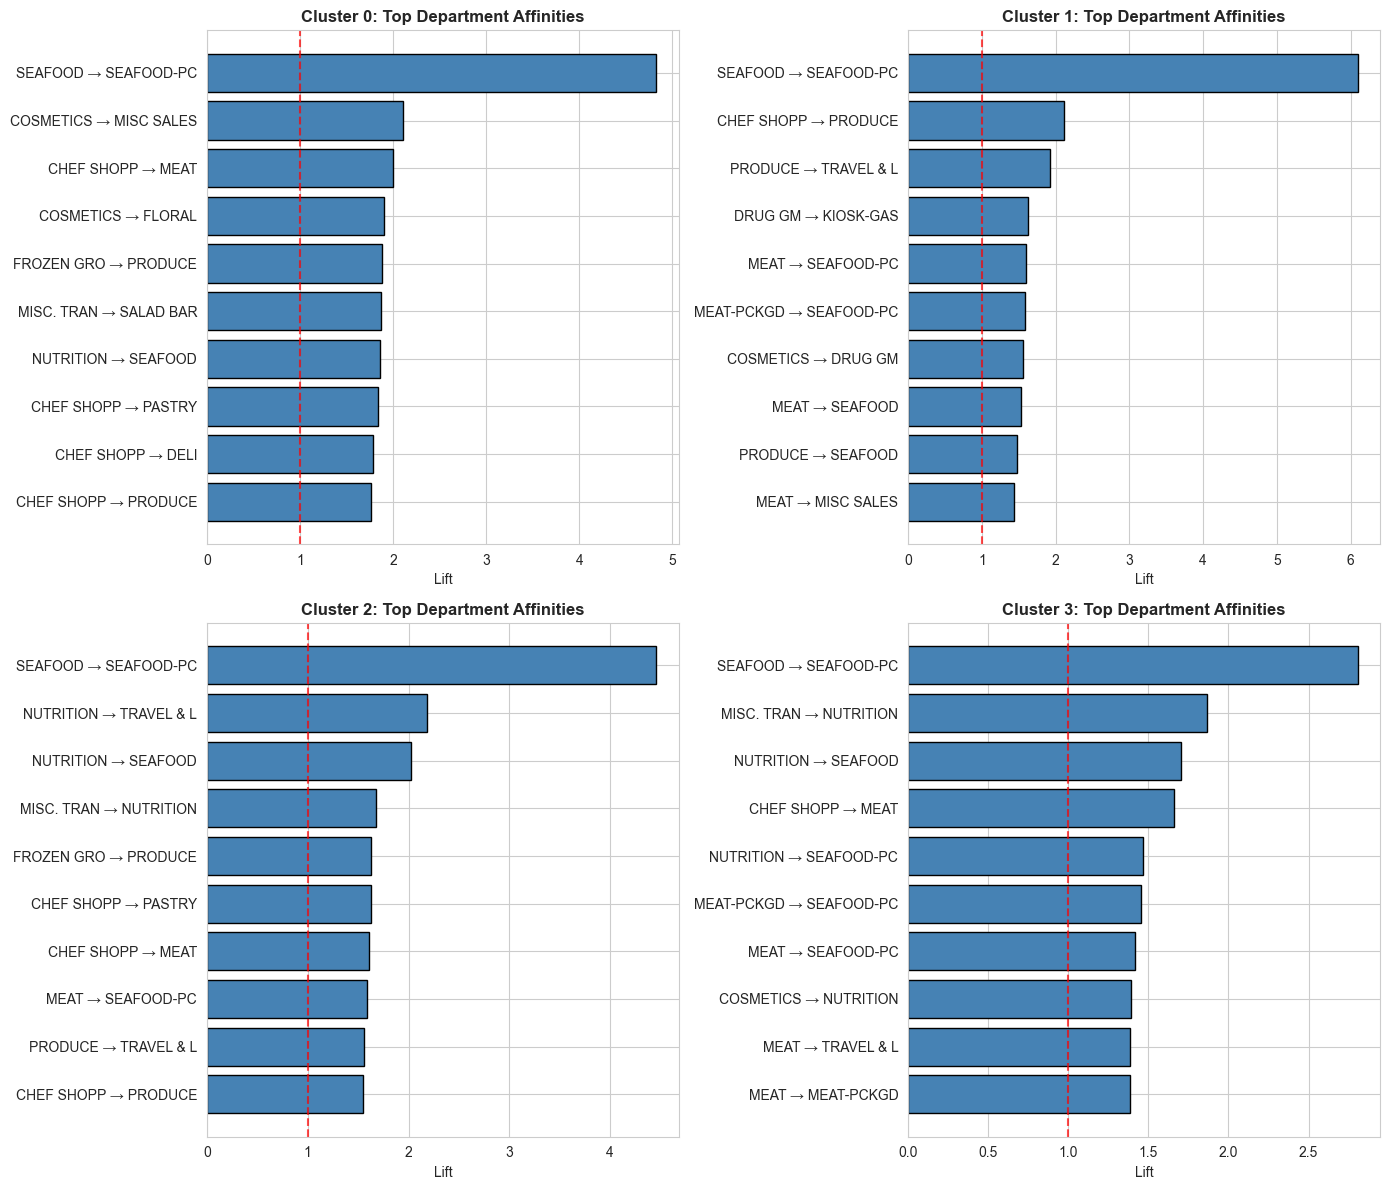

In [82]:
# Visualise top department affinities per cluster

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for cluster_id, ax in enumerate(axes.flatten()):
    if cluster_id in dept_affinity_by_cluster:
        df = dept_affinity_by_cluster[cluster_id].head(10).sort_values('lift', ascending=True)
        
        labels = df['category_A'].str[:10] + ' → ' + df['category_B'].str[:10]
        ax.barh(labels, df['lift'], color='steelblue', edgecolor='black')
        ax.set_xlabel('Lift', fontsize=10)
        ax.set_title(f'Cluster {cluster_id}: Top Department Affinities', fontsize=12, fontweight='bold')
        ax.axvline(x=1, color='red', linestyle='--', alpha=0.7)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'Cluster {cluster_id}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [83]:
# PART B: COMMODITY-LEVEL AFFINITY BY CLUSTER

print("=" * 100)
print("COMMODITY-LEVEL AFFINITY PATTERNS BY CLUSTER")
print("=" * 100)

commodity_affinity_by_cluster = {}

for cluster_id in sorted(transactions_clustered['cluster'].unique()):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*50}")
    
    # Filter transactions to this cluster
    cluster_transactions = transactions_clustered[transactions_clustered['cluster'] == cluster_id]
    
    print(f"Baskets in cluster: {cluster_transactions['BASKET_ID'].nunique():,}")
    
    # Calculate affinity (lower min_pair_count for commodity level as it's more granular)
    cluster_affinity = calculate_affinity_for_cluster(
        cluster_transactions, 
        level='COMMODITY_DESC', 
        min_pair_count=20
        
    )
    
    if len(cluster_affinity) > 0:
        cluster_affinity = cluster_affinity.sort_values('lift', ascending=False)
        commodity_affinity_by_cluster[cluster_id] = cluster_affinity
        
        print(f"Affinity pairs found: {len(cluster_affinity)}")
        print(f"\nTop 10 Commodity Pairs by Lift:")
        display(cluster_affinity.head(10))
    else:
        print("No significant affinity pairs found.")

COMMODITY-LEVEL AFFINITY PATTERNS BY CLUSTER

CLUSTER 0
Baskets in cluster: 98,375
Affinity pairs found: 18813

Top 10 Commodity Pairs by Lift:


,category_A,category_B,pair_count,support,lift
8819,CONDIMENTS,PREPARED/PKGD FOODS,20,0.000276,70.764347
16342,CEREAL/BREAKFAST,CONDIMENTS,21,0.000290,33.852804
7071,FROZEN,PREPARED/PKGD FOODS,38,0.000525,32.231706
7059,CEREAL/BREAKFAST,PREPARED/PKGD FOODS,37,0.000511,32.116763
15803,PREPARED/PKGD FOODS,SNKS/CKYS/CRKR/CNDY,22,0.000304,30.383948
14004,FLORAL-FRESH CUT,ROSES,26,0.000359,23.771944
14300,CHIPS&SNACKS,CONDIMENTS,20,0.000276,23.388216
13354,FLORAL BALLOONS,FLORAL-FRESH CUT,24,0.000331,22.734084
16770,CEREAL/BREAKFAST,NON-DAIRY BEVERAGES,20,0.000276,21.425825
15790,BABYFOOD,REFRIGERATED,32,0.000442,20.604380



CLUSTER 1
Baskets in cluster: 90,546
Affinity pairs found: 11312

Top 10 Commodity Pairs by Lift:


,category_A,category_B,pair_count,support,lift
10979,FLORAL BALLOONS,FLORAL-FRESH CUT,20,0.000304,44.316130
8594,SEAFOOD - MISC,SEAFOOD-FRESH,44,0.000669,30.507421
9042,BABY FOODS,INFANT FORMULA,190,0.002889,26.324342
5586,CHIPS&SNACKS,FROZEN,20,0.000304,24.071878
6441,BABY HBC,DIAPERS & DISPOSABLES,169,0.002569,23.429418
8899,BATH,HAND/BODY/FACIAL PRODUCTS,29,0.000441,22.527471
10871,DISPOSIBLE FOILWARE,SPRING/SUMMER SEASONAL,28,0.000426,22.315182
7574,FROZEN,REFRIGERATED,67,0.001019,22.032527
82,LAUNDRY ADDITIVES,LAUNDRY DETERGENTS,280,0.004257,21.595946
7589,COOKWARE & BAKEWARE,KITCHEN GADGETS,28,0.000426,20.423537



CLUSTER 2
Baskets in cluster: 67,469
Affinity pairs found: 17881

Top 10 Commodity Pairs by Lift:


,category_A,category_B,pair_count,support,lift
9418,CONDIMENTS,PREPARED/PKGD FOODS,27,0.000502,74.844423
9420,CONDIMENTS,SNKS/CKYS/CRKR/CNDY,27,0.000502,37.167638
15953,CHIPS&SNACKS,CONDIMENTS,39,0.000725,32.883036
3731,CONDIMENTS,FROZEN,35,0.000650,32.789352
8651,NON-DAIRY BEVERAGES,SNKS/CKYS/CRKR/CNDY,29,0.000539,24.467585
15330,DOMESTIC WINE,LAMB,41,0.000762,23.287716
3750,FROZEN,NON-DAIRY BEVERAGES,40,0.000743,22.967657
8645,FROZEN,SNKS/CKYS/CRKR/CNDY,49,0.000910,20.766590
12039,CHIPS&SNACKS,SNKS/CKYS/CRKR/CNDY,54,0.001003,20.597066
8641,CEREAL/BREAKFAST,SNKS/CKYS/CRKR/CNDY,55,0.001022,19.402075



CLUSTER 3
Baskets in cluster: 19,737
Affinity pairs found: 17679

Top 10 Commodity Pairs by Lift:


,category_A,category_B,pair_count,support,lift
16196,BAKING,CONDIMENTS,24,0.001554,38.554307
16198,BAKING,PREPARED/PKGD FOODS,42,0.002720,31.771605
16205,CONDIMENTS,PREPARED/PKGD FOODS,33,0.002137,30.292670
16200,BAKING,SNKS/CKYS/CRKR/CNDY,36,0.002331,19.949612
15835,CHIPS&SNACKS,CONDIMENTS,40,0.002591,19.277154
16194,BAKING,CEREAL/BREAKFAST,46,0.002979,18.067918
9203,CANDLES/ACCESSORIES,JUICE,40,0.002591,17.528166
16195,BAKING,CHIPS&SNACKS,43,0.002785,17.077238
16207,CONDIMENTS,SNKS/CKYS/CRKR/CNDY,25,0.001619,16.811471
16519,BEVERAGE,SNKS/CKYS/CRKR/CNDY,22,0.001425,16.666765


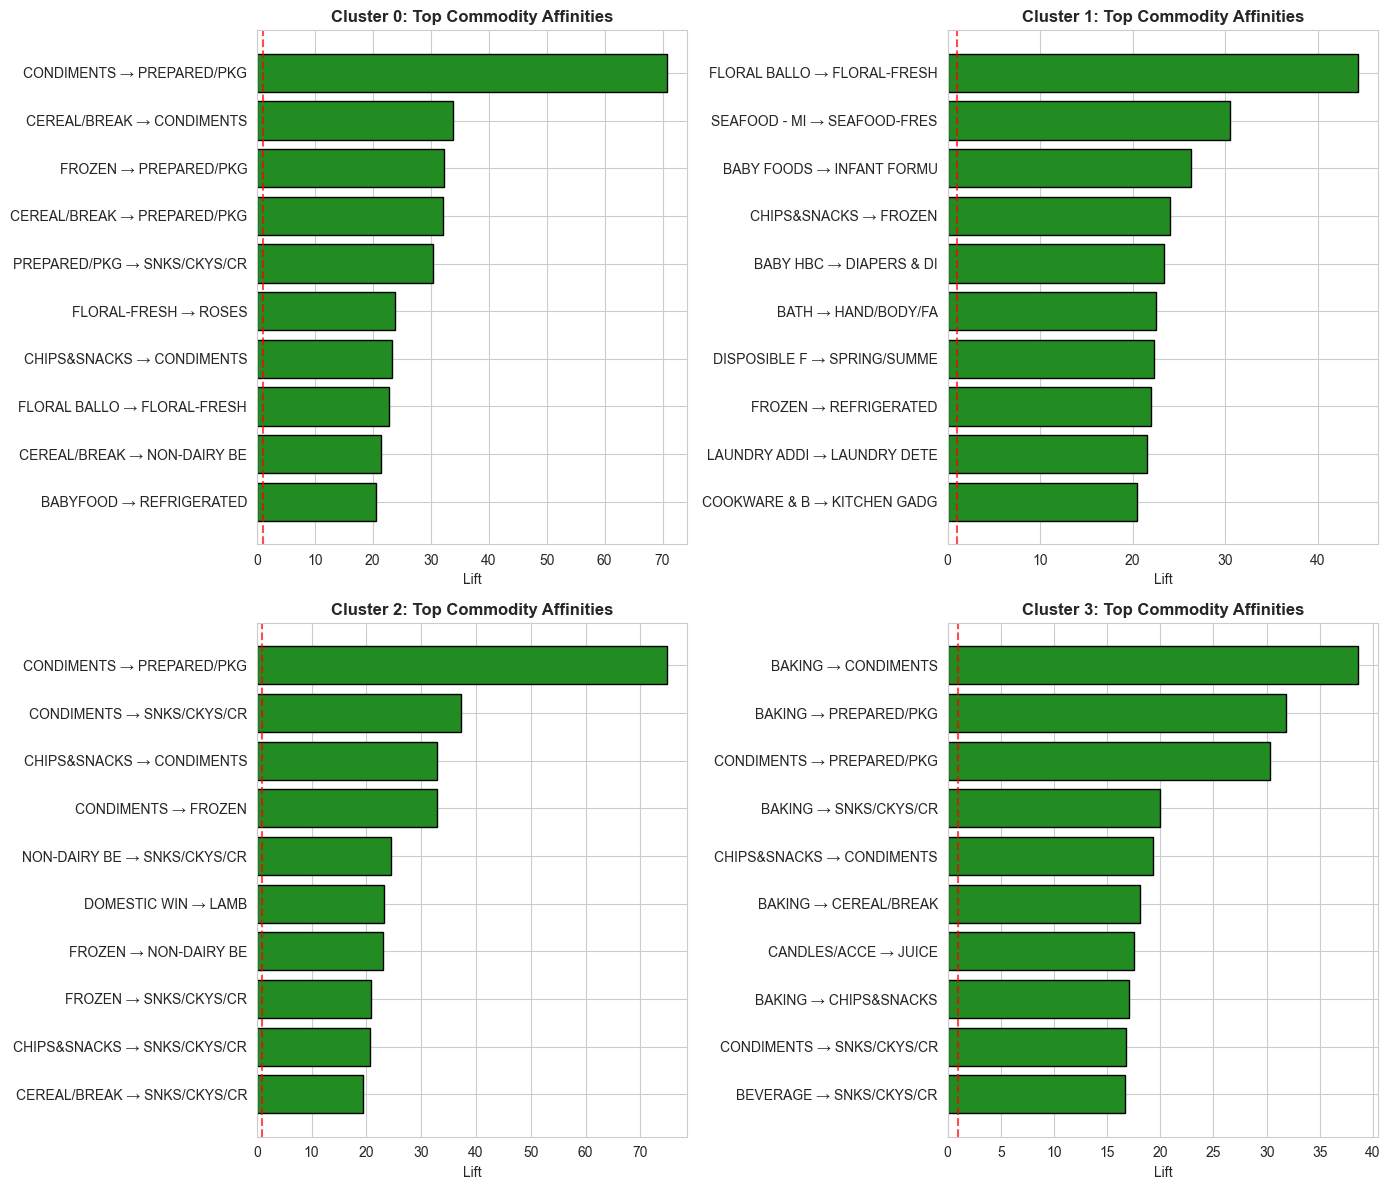

In [84]:
# Visualise top commodity affinities per cluster

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

for cluster_id, ax in enumerate(axes.flatten()):
    if cluster_id in commodity_affinity_by_cluster:
        df = commodity_affinity_by_cluster[cluster_id].head(10).sort_values('lift', ascending=True)
        
        labels = df['category_A'].str[:12] + ' → ' + df['category_B'].str[:12]
        ax.barh(labels, df['lift'], color='forestgreen', edgecolor='black')
        ax.set_xlabel('Lift', fontsize=10)
        ax.set_title(f'Cluster {cluster_id}: Top Commodity Affinities', fontsize=12, fontweight='bold')
        ax.axvline(x=1, color='red', linestyle='--', alpha=0.7)
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', fontsize=12)
        ax.set_title(f'Cluster {cluster_id}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [85]:
# Save results

# Combine all cluster affinities into single DataFrames
dept_affinity_all = pd.concat([
    df.assign(cluster=cluster_id) 
    for cluster_id, df in dept_affinity_by_cluster.items()
])

commodity_affinity_all = pd.concat([
    df.assign(cluster=cluster_id) 
    for cluster_id, df in commodity_affinity_by_cluster.items()
])



✓ Saved: dept_affinity_by_cluster.csv
✓ Saved: commodity_affinity_by_cluster.csv


In [86]:
# Summary: Compare top affinities across clusters

print("\n" + "=" * 100)
print("SUMMARY: TOP 3 DEPARTMENT AFFINITIES PER CLUSTER")
print("=" * 100)

for cluster_id in sorted(dept_affinity_by_cluster.keys()):
    print(f"\nCluster {cluster_id}:")
    top3 = dept_affinity_by_cluster[cluster_id].head(3)
    for _, row in top3.iterrows():
        print(f"  • {row['category_A']} → {row['category_B']} (lift: {row['lift']:.2f})")

print("\n" + "=" * 100)
print("SUMMARY: TOP 3 COMMODITY AFFINITIES PER CLUSTER")
print("=" * 100)

for cluster_id in sorted(commodity_affinity_by_cluster.keys()):
    print(f"\nCluster {cluster_id}:")
    top3 = commodity_affinity_by_cluster[cluster_id].head(3)
    for _, row in top3.iterrows():
        print(f"  • {row['category_A']} → {row['category_B']} (lift: {row['lift']:.2f})")


SUMMARY: TOP 3 DEPARTMENT AFFINITIES PER CLUSTER

Cluster 0:
  • SEAFOOD → SEAFOOD-PCKGD (lift: 4.83)
  • COSMETICS → MISC SALES TRAN (lift: 2.10)
  • CHEF SHOPPE → MEAT (lift: 2.00)

Cluster 1:
  • SEAFOOD → SEAFOOD-PCKGD (lift: 6.09)
  • CHEF SHOPPE → PRODUCE (lift: 2.12)
  • PRODUCE → TRAVEL & LEISUR (lift: 1.93)

Cluster 2:
  • SEAFOOD → SEAFOOD-PCKGD (lift: 4.46)
  • NUTRITION → TRAVEL & LEISUR (lift: 2.19)
  • NUTRITION → SEAFOOD (lift: 2.03)

Cluster 3:
  • SEAFOOD → SEAFOOD-PCKGD (lift: 2.81)
  • MISC. TRANS. → NUTRITION (lift: 1.86)
  • NUTRITION → SEAFOOD (lift: 1.70)

SUMMARY: TOP 3 COMMODITY AFFINITIES PER CLUSTER

Cluster 0:
  • CONDIMENTS → PREPARED/PKGD FOODS (lift: 70.76)
  • CEREAL/BREAKFAST → CONDIMENTS (lift: 33.85)
  • FROZEN → PREPARED/PKGD FOODS (lift: 32.23)

Cluster 1:
  • FLORAL BALLOONS → FLORAL-FRESH CUT (lift: 44.32)
  • SEAFOOD - MISC → SEAFOOD-FRESH (lift: 30.51)
  • BABY FOODS → INFANT FORMULA (lift: 26.32)

Cluster 2:
  • CONDIMENTS → PREPARED/PKGD FOOD

In [87]:
# =============================================================================
# TASK 6: RECOMMENDATION ENGINE - SIMPLE PERSONALISED APPROACH
# =============================================================================

# Step 6.1: Prepare affinity lookup from commodity_affinity

# Confirm commodity_affinity has the required columns
print("Columns in commodity_affinity:")
print(cross_commodity_affinity.columns.tolist())

# Build lookup dictionary using directional confidence (not averaged)
affinity_lookup = {}

for _, row in cross_commodity_affinity.iterrows():
    comm_a = row['COMMODITY_DESC_A']
    comm_b = row['COMMODITY_DESC_B']
    
    # A triggers recommendation of B: use confidence_A_to_B
    affinity_lookup[(comm_a, comm_b)] = {
        'score': row['avg_lift'] * row['confidence_A_to_B'],
        'lift': row['avg_lift'],
        'confidence': row['confidence_A_to_B']
    }
    
    # B triggers recommendation of A: use confidence_B_to_A
    affinity_lookup[(comm_b, comm_a)] = {
        'score': row['avg_lift'] * row['confidence_B_to_A'],
        'lift': row['avg_lift'],
        'confidence': row['confidence_B_to_A']
    }

print(f"\nAffinity lookup entries: {len(affinity_lookup):,}")

Columns in commodity_affinity:
['COMMODITY_DESC_A', 'COMMODITY_DESC_B', 'pair_count', 'support', 'lift_A_to_B', 'lift_B_to_A', 'confidence_A_to_B', 'confidence_B_to_A', 'avg_lift', 'avg_confidence', 'opportunity_score']

Affinity lookup entries: 1,194


In [88]:
# Step 6.2: Prepare basket data from meaningful_baskets

meaningful_basket_ids = meaningful_baskets['BASKET_ID'].unique()

basket_transactions = transaction_data[
    transaction_data['BASKET_ID'].isin(meaningful_basket_ids)
].merge(
    product_data[['PRODUCT_ID', 'COMMODITY_DESC']],
    on='PRODUCT_ID',
    how='left'
)

# Remove blank commodities
basket_transactions = basket_transactions[
    (basket_transactions['COMMODITY_DESC'].notna()) &
    (basket_transactions['COMMODITY_DESC'] != ' ') &
    (basket_transactions['COMMODITY_DESC'].str.strip() != '')
]

# Build basket data: list of (product_id, commodity) per basket
basket_products = basket_transactions.groupby('BASKET_ID').apply(
    lambda x: list(zip(x['PRODUCT_ID'], x['COMMODITY_DESC']))
).reset_index()
basket_products.columns = ['BASKET_ID', 'products']

# Filter to 3+ items
basket_products = basket_products[basket_products['products'].apply(len) >= 3]

print(f"Baskets prepared: {len(basket_products):,}")

Baskets prepared: 150,118


In [89]:
# Step 6.3: Recommendation function

def get_recommendations_for_basket(basket_id, basket_data, affinity_lookup, top_n=6):
    """
    Generate recommendations by hiding the last item and predicting it.
    
    Parameters:
    -----------
    basket_id : int
        The BASKET_ID to generate recommendations for
    basket_data : DataFrame
        DataFrame with ['BASKET_ID', 'products'] where products is list of 
        (product_id, commodity) tuples
    affinity_lookup : dict
        Dictionary: (trigger_commodity, target_commodity) -> {score, lift, confidence}
    top_n : int
        Number of recommendations to return
    
    Returns:
    --------
    dict with basket_id, hidden_commodity, visible_commodities, recommendations, hit, hit_rank
    """
    
    basket_row = basket_data[basket_data['BASKET_ID'] == basket_id]
    
    if len(basket_row) == 0:
        return {'error': f'Basket {basket_id} not found'}
    
    products = basket_row.iloc[0]['products']
    
    if len(products) < 3:
        return {'error': f'Basket {basket_id} has fewer than 3 products'}
    
    # Hide the last item
    hidden_commodity = products[-1][1]
    visible_commodities = list(set([p[1] for p in products[:-1]]))
    
    # Generate recommendations
    recommendation_scores = {}
    
    for visible_commodity in visible_commodities:
        for (trigger, target), aff_data in affinity_lookup.items():
            if trigger == visible_commodity and target not in visible_commodities:
                if target not in recommendation_scores:
                    recommendation_scores[target] = 0
                recommendation_scores[target] += aff_data['score']
    
    # Rank by score
    ranked_recommendations = sorted(
        recommendation_scores.items(),
        key=lambda x: x[1],
        reverse=True
    )[:top_n]
    
    top_commodities = [comm for comm, _ in ranked_recommendations]
    hit = hidden_commodity in top_commodities
    
    return {
        'basket_id': basket_id,
        'hidden_commodity': hidden_commodity,
        'visible_commodities': visible_commodities,
        'recommendations': ranked_recommendations,
        'hit': hit,
        'hit_rank': top_commodities.index(hidden_commodity) + 1 if hit else None
    }

In [90]:
# Step 6.4: Test examples

print("=" * 100)
print("RECOMMENDATION ENGINE - EXAMPLE PREDICTIONS")
print("=" * 100)

sample_basket_ids = basket_products['BASKET_ID'].sample(5, random_state=42).tolist()

for basket_id in sample_basket_ids:
    result = get_recommendations_for_basket(basket_id, basket_products, affinity_lookup, top_n=6)
    
    if 'error' in result:
        print(f"\n{result['error']}")
        continue
    
    #print(f"\n📦 Basket: {result['basket_id']}")
    #print(f"   Visible: {result['visible_commodities']}")
    #print(f"   Hidden: {result['hidden_commodity']}")
    #print(f"   Top 3 Recommendations:")
    for i, (comm, score) in enumerate(result['recommendations'], 1):
        marker = "+" if comm == result['hidden_commodity'] else " "
        print(f"      {i}. {comm} (score: {score:.2f}) {marker}")
    print(f"   HIT: {'+' if result['hit'] else '-'}")

RECOMMENDATION ENGINE - EXAMPLE PREDICTIONS
      1. TROPICAL FRUIT (score: 2.03)  
      2. FLUID MILK PRODUCTS (score: 0.99)  
      3. MILK BY-PRODUCTS (score: 0.53)  
      4. CARROTS (score: 0.50)  
      5. PEPPERS-ALL (score: 0.38)  
      6. EGGS (score: 0.35)  
   HIT: -
      1. TROPICAL FRUIT (score: 7.67)  
      2. PEPPERS-ALL (score: 2.29)  
      3. BROCCOLI/CAULIFLOWER (score: 1.95)  
      4. ONIONS (score: 1.66)  
      5. FLUID MILK PRODUCTS (score: 1.55)  
      6. EGGS (score: 1.43)  
   HIT: -
      1. TROPICAL FRUIT (score: 3.91)  
      2. FLUID MILK PRODUCTS (score: 1.58) +
      3. BAKED BREAD/BUNS/ROLLS (score: 0.69)  
      4. CHEESES (score: 0.62)  
      5. CHEESE (score: 0.47)  
      6. CARROTS (score: 0.30)  
   HIT: +
      1. TROPICAL FRUIT (score: 7.41)  
      2. PEPPERS-ALL (score: 1.66)  
      3. CARROTS (score: 1.12)  
      4. VEGETABLES - ALL OTHERS (score: 1.09)  
      5. VEGETABLES SALAD (score: 1.03)  
      6. SOUP (score: 1.01)  
   HIT:

In [91]:
# Step 6.5: Evaluate on held-out test data

from sklearn.model_selection import train_test_split

train_baskets, test_baskets = train_test_split(
    basket_products, 
    test_size=0.2, 
    random_state=42
)

print(f"Training baskets: {len(train_baskets):,}")
print(f"Test baskets: {len(test_baskets):,}")

results = []

for _, row in test_baskets.iterrows():
    result = get_recommendations_for_basket(row['BASKET_ID'], test_baskets, affinity_lookup, top_n=6)
    
    if 'error' not in result:
        results.append({
            'basket_id': result['basket_id'],
            'hidden_commodity': result['hidden_commodity'],
            'hit': result['hit'],
            'hit_rank': result['hit_rank'],
            'num_visible': len(result['visible_commodities'])
        })

results_df = pd.DataFrame(results)
print(f"Baskets evaluated: {len(results_df):,}")

Training baskets: 120,094
Test baskets: 30,024
Baskets evaluated: 30,024


In [92]:
# Step 6.6: Calculate metrics

hit_rate_at_1 = (results_df['hit_rank'] == 1).mean()
hit_rate_at_2 = (results_df['hit_rank'] <= 2).mean()
hit_rate_at_3 = (results_df['hit_rank'] <= 3).mean()
hit_rate_at_4 = (results_df['hit_rank'] <= 4).mean()
hit_rate_at_5 = (results_df['hit_rank'] <= 5).mean()
hit_rate_at_6 = (results_df['hit_rank'] <= 6).mean()

results_df['reciprocal_rank'] = results_df['hit_rank'].apply(lambda x: 1/x if pd.notna(x) else 0)
mrr = results_df['reciprocal_rank'].mean()

print("=" * 100)
print("RECOMMENDATION ENGINE EVALUATION")
print("=" * 100)
print(f"\nTest baskets: {len(results_df):,}")
print(f"\nHit Rate @ 1: {hit_rate_at_1:.1%}")
print(f"Hit Rate @ 2: {hit_rate_at_2:.1%}")
print(f"Hit Rate @ 3: {hit_rate_at_3:.1%}")
print(f"Hit Rate @ 4: {hit_rate_at_4:.1%}")
print(f"Hit Rate @ 5: {hit_rate_at_5:.1%}")
print(f"Hit Rate @ 6: {hit_rate_at_6:.1%}")

RECOMMENDATION ENGINE EVALUATION

Test baskets: 30,024

Hit Rate @ 1: 1.0%
Hit Rate @ 2: 2.9%
Hit Rate @ 3: 3.9%
Hit Rate @ 4: 4.8%
Hit Rate @ 5: 5.4%
Hit Rate @ 6: 6.2%


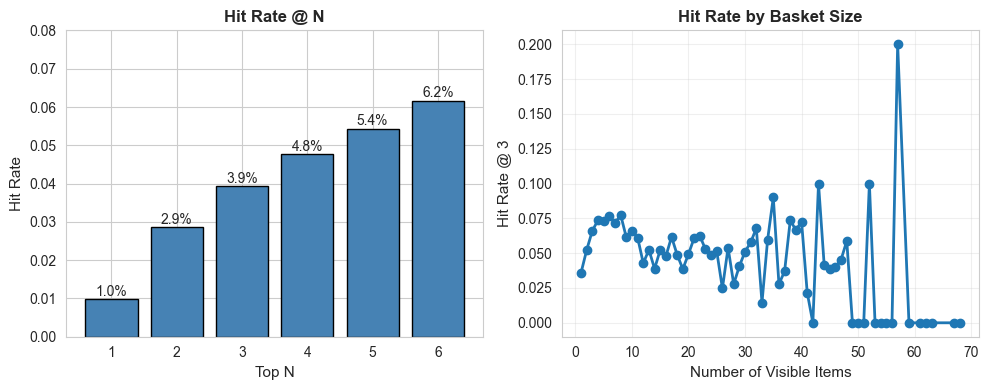

In [93]:
# Step 6.7: Visualise results

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Hit rate at K
ax1 = axes[0]
k_values = [1, 2, 3, 4, 5, 6]
hit_rates = [hit_rate_at_1, hit_rate_at_2, hit_rate_at_3, hit_rate_at_4, hit_rate_at_5, hit_rate_at_6]
ax1.bar(k_values, hit_rates, color='steelblue', edgecolor='black')
ax1.set_xlabel('Top N', fontsize=11)
ax1.set_ylabel('Hit Rate', fontsize=11)
ax1.set_title('Hit Rate @ N', fontsize=12, fontweight='bold')
ax1.set_xticks(k_values)
for i, v in enumerate(hit_rates):
    ax1.text(k_values[i], v + 0.001, f'{v:.1%}', ha='center')
ax1.set_ylim(0, 0.08)

# Hit rate by basket size
ax2 = axes[1]
hit_by_size = results_df.groupby('num_visible')['hit'].mean()
ax2.plot(hit_by_size.index, hit_by_size.values, marker='o', linewidth=2)
ax2.set_xlabel('Number of Visible Items', fontsize=11)
ax2.set_ylabel('Hit Rate @ 3', fontsize=11)
ax2.set_title('Hit Rate by Basket Size', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()